# 现代架构演进

> Part 1 我们实现了 MiniGPT——一个能预测下一个 token 的小模型。它的 Block 用的是最朴素的零件：Post-Norm、ReLU FFN、正弦位置编码。
>
> 这一节从那个朴素 Block 出发，依次替换归一化层、激活函数、位置编码和注意力机制，看每一处改进具体解决了什么问题。

Part 2 关心的是「怎么把 MiniGPT 变成真正可用的 LLM」。从架构到训练，每个环节都有改进空间。这一节先看架构，特别是 Block 内部的零件升级。

先澄清一个名字上的误会：标题写「GPT-2 到现代模型」，不是说 GPT-2 用的就是原始 Transformer 的 Post-Norm + ReLU 配方。GPT-2 实际上已经用了 Pre-LN、GELU 和可学习的位置嵌入。这一节的对比对象不是 GPT-2 的真实代码，而是 Part 1 那个为了教学写出来的 MiniGPT，它代表了原始 Transformer 里最容易理解的一组零件。

## Decoder-Only 架构

Transformer 原论文同时包含 Encoder 和 Decoder，但现代 LLM 几乎都只保留了 Decoder。

一个直觉是：Decoder-Only 把所有任务都统一成了「继续往后写」。翻译可以写成 `英文：I love you\n中文：`，让模型继续写「我爱你」；问答可以写成 `问题：太阳为什么会发光？\n回答：`，让模型继续写答案。写代码、总结、推理、对话，本质上都是「给一段前缀，让模型预测后面的 token」。

Encoder-Only（比如 BERT）擅长看完整句话做理解，但无法直接生成文本；Encoder-Decoder（比如 T5）可以生成，但结构更复杂，训练和推理时需要同时维护两端。Decoder-Only 只关心一件事：根据已经看到的内容预测下一个 token。

数据格式也因此变得简单。一段长度为 1000 的文本，Decoder-Only 在每个位置都能产生训练信号：第 1 个 token 预测第 2 个，第 2 个预测第 3 个，一直到末尾。loss 定义、模型目标都简单。

推理时也有工程上的便利。自回归生成每次只新增一个 token，历史 token 的 K、V 可以缓存在 KV Cache 里，下一轮只算新 token 对历史的 Attention。增量计算让推理优化变得很自然。

理解能力不是通过单独接一个 Encoder 实现的，而是在海量「预测下一个 token」的过程中自然产生的。

架构确定为 Decoder-Only 之后，Block 内部的每个零件就成了优化的重点。从 2017 年到现在，几乎每个组件都被替换过：

| 教学版零件 | 现代替代 | 解决的问题 |
|:---|:---|:---|
| Post-Norm | Pre-Norm（+ RMSNorm） | 深层训练梯度不稳定 |
| ReLU | GELU / SwiGLU | 负数区梯度消失 |
| 正弦位置编码 | RoPE | 长度外推能力差 |
| 标准 MHA | GQA / MLA | 长上下文 KV Cache 显存过大 |

每一行对应一个具体的工程问题。下面几节按这个顺序展开：先看归一化层，再看 FFN 的激活函数，再看归一化在残差中的位置，最后是位置编码和注意力机制。

## 教学版 Transformer Block

我们先回顾教学版 Block 的实现，后面的修改都在它上面进行。

代码里有一处写法需要解释：`self.attention(x, x, x)`。`nn.MultiheadAttention` 接收 3 个输入 Query、Key、Value，分别对应：

- **Query**：当前位置想找什么信息
- **Key**：每个位置能提供什么线索
- **Value**：真正被取出来混合的信息

在 Self-Attention 里，Q、K、V 都来自同一串 token 向量 `x`。写成 `attention(x, x, x)` 表示 Attention 层内部用三套不同的线性投影，把同一个 `x` 投影成 Q、K、V。

如果是 Cross-Attention，输入就不一定是三个 `x`。比如 Decoder 拿自己的状态当 Query，拿 Encoder 的输出当 Key 和 Value。

In [1]:
# === 这就是 教学版 MiniGPT 的版本，我们接下来的「改造对象」 ===

import torch.nn as nn
import torch.nn.functional as F

class FeedForward_Old(nn.Module):
    """原始 FFN：两层 Linear，中间 ReLU"""
    def __init__(self, d_model, d_ff=None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))

class TransformerBlock_Old(nn.Module):
    """Post-Norm + LayerNorm + ReLU FFN（教学版）"""
    def __init__(self, d_model, num_heads, d_ff=None):
        super().__init__()
        self.attention = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.ffn = FeedForward_Old(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)  # ← 普通 LayerNorm
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        # Self-Attention: Q、K、V 都来自同一个 x
        # mask 用来挡住未来 token，避免 Decoder 偷看答案
        attn_out, _ = self.attention(
            x, x, x,
            attn_mask=mask,
            need_weights=False,
        )

        # Post-Norm: 先算子层，再 +残差，最后 Norm
        x = self.norm1(x + attn_out)
        x = self.norm2(x + self.ffn(x))
        return x

print("✅ 这是教学版 MiniGPT 的版本。接下来我们逐个升级。")
print("升级路线: LayerNorm→RMSNorm → ReLU→SwiGLU → Post-Norm→Pre-Norm")


✅ 这是教学版 MiniGPT 的版本。接下来我们逐个升级。
升级路线: LayerNorm→RMSNorm → ReLU→SwiGLU → Post-Norm→Pre-Norm


## 组件升级

教学版 Block 里有三个零件在现代 LLM 里几乎都被换掉了：归一化层、FFN 的激活函数、归一化在残差中的位置。每一处都对应一个具体的工程问题——计算冗余、表达能力、深层训练稳定性。下面三节按这个顺序展开，每节先手算旧版本的算法、观察问题，再换上新版本。

**LayerNorm 手算**

假设一个 token 的向量是 `[1, 3, 5, 7]`（4 维，为了手算方便，这里也取 4 维）。

LayerNorm 做的事是把这个向量的均值变成 0，标准差变成 1。可以类比为对一组分数做标准化：不管原始数值高低，处理后均值为 0，分散程度统一。

方差的计算是最容易卡住的地方。它的含义是这一组数字离平均值的分散程度。

先看每个数离平均值多远：

```text
平均值 μ = 4

1 离 4 差 -3
3 离 4 差 -1
5 离 4 差  1
7 离 4 差  3
```

如果直接把这些差值相加：

```text
(-3) + (-1) + 1 + 3 = 0
```

`[1, 3, 5, 7]` 明明是分散的，但正数和负数互相抵消，结果看起来像完全不分散。所以不能直接平均差值。

解决方法是把每个差值平方：

```text
(-3)² = 9
(-1)² = 1
 1²  = 1
 3²  = 9
```

平方有两个作用：负数变成正数不会互相抵消；离平均值越远惩罚越大，比如差 3 变成 9。

最后再求平均：

```text
方差 σ² = (9 + 1 + 1 + 9) / 4 = 5
```

方差的含义是平均来看每个数字偏离均值的平方有多大。

具体步骤：
```
1. 算均值  μ = (x₁ + x₂ + x₃ + x₄) / 4
2. 算每个数离均值的差：x₁-μ, x₂-μ, x₃-μ, x₄-μ
3. 把差平方，避免正负抵消：(x₁-μ)², (x₂-μ)², ...
4. 对平方后的差求平均，得到方差 σ²
5. 算标准差 σ = √σ²
6. 归一化 x' = (x - μ) / σ
7. 缩放   y = γ × x' + β
```

这里除以 4，是因为就在这个 token 的 4 个维度上做平均。PyTorch 的 `LayerNorm` 也是把当前向量的所有维度当成一组数，计算它们自己的均值和方差。

γ 和 β 是可学习的参数，让模型自己决定归一化之后「放多大」「往哪偏」。

下面用 `[1, 3, 5, 7]` 手算一遍：

In [2]:
# === LayerNorm 手工计算 ===
import torch

print("=== LayerNorm 手算：输入 x = [1, 3, 5, 7] ===")
print()

x = torch.tensor([1.0, 3.0, 5.0, 7.0])

# Step 1: 均值
mu = x.mean()
print(f"Step 1 — 均值 μ = (1+3+5+7)/4 = {mu:.1f}")

# Step 2: 方差（这里除以 N，不是 N-1）
var = torch.mean((x - mu) ** 2)
print(f"Step 2 — 方差 σ² = ((1-4)²+(3-4)²+(5-4)²+(7-4)²)/4")
print(f"        = (9 + 1 + 1 + 9)/4 = {var:.1f}")

# Step 3: 标准差
sigma = torch.sqrt(var)
print(f"Step 3 — 标准差 σ = √{var:.1f} = {sigma:.4f}")

# Step 4: 归一化
x_norm = (x - mu) / sigma
print(f"Step 4 — 归一化: (x - 4)/{sigma:.4f}")
for i, (xi, xni) in enumerate(zip(x.tolist(), x_norm.tolist())):
    print(f"         x[{i}] = ({xi:.1f} - 4) / {sigma:.4f} = {xni: .4f}")

print(f"         归一化后: {[f'{v:.4f}' for v in x_norm.tolist()]}")
print(f"         均值: {x_norm.mean():.4f} (=0), 标准差: {x_norm.std(unbiased=False):.4f} (=1)")

# Step 5: 缩放（假设 γ=[1,1,1,1], β=[0,0,0,0]）
# 初始时 γ 全 1，β 全 0，所以输出就是 x_norm
print(f"Step 5 — 缩放: γ=1, β=0 时输出 = 归一化结果")
print(f"         γ 和 β 是随着训练学出来的，让模型自己决定怎么调")


=== LayerNorm 手算：输入 x = [1, 3, 5, 7] ===

Step 1 — 均值 μ = (1+3+5+7)/4 = 4.0
Step 2 — 方差 σ² = ((1-4)²+(3-4)²+(5-4)²+(7-4)²)/4
        = (9 + 1 + 1 + 9)/4 = 5.0
Step 3 — 标准差 σ = √5.0 = 2.2361
Step 4 — 归一化: (x - 4)/2.2361
         x[0] = (1.0 - 4) / 2.2361 = -1.3416
         x[1] = (3.0 - 4) / 2.2361 = -0.4472
         x[2] = (5.0 - 4) / 2.2361 =  0.4472
         x[3] = (7.0 - 4) / 2.2361 =  1.3416
         归一化后: ['-1.3416', '-0.4472', '0.4472', '1.3416']
         均值: 0.0000 (=0), 标准差: 1.0000 (=1)
Step 5 — 缩放: γ=1, β=0 时输出 = 归一化结果
         γ 和 β 是随着训练学出来的，让模型自己决定怎么调


**LayerNorm 的问题**

LayerNorm 在每个 token、每一层都要算两个统计量：μ 和 σ²。σ² 的计算又依赖 μ——必须先遍历一遍算出均值，再遍历一遍算每个维度偏离均值多少。一次 LayerNorm 等于遍历数据两遍，外加一次开方。

在 MiniGPT 这种小模型里这点开销可以忽略，但当模型规模放大到几十亿参数、几十层、序列长度上千时，归一化的计算量累积起来成为一个真实的瓶颈。RMSNorm（Zhang & Sennrich, 2019）针对的就是这个问题。

要解释为什么可以去掉去均值这一步，先把 LayerNorm 的作用拆开看：

```text
LayerNorm(x) = (x - μ) / σ × γ + β
                └── re-centering ──┘└── re-scaling ──┘
```

- **re-centering**（减去 μ）：把激活值的中心移到 0
- **re-scaling**（除以 σ）：把激活值的幅度统一到相近量级

这两件事的权重并不对等。re-scaling 是稳定训练的关键——它防止激活值随层数加深而指数级爆炸或消失，这是深层 Transformer 能训练起来的前提。re-centering 的作用相对次要：网络里每一个线性层（W_Q、W_K、W_V、FFN 的两个全连接层）都带 bias 项，本身就具备平移能力，能把任意均值移到合适的位置。换句话说，LayerNorm 的减均值和下游层的 bias 在功能上是重叠的。

RMSNorm 的核心思路是既然 re-scaling 才是关键、re-centering 可由 bias 替代，那就只保留 re-scaling。论文的实验结论是：在 Transformer 的各种任务上，RMSNorm 与 LayerNorm 的精度几乎相同，但归一化这一步的计算时间明显下降（论文报告降幅在 7%~64% 区间，具体取决于模型规模和序列长度）。LLaMA、Qwen、Mistral、DeepSeek 等主流开源 LLM 都改用 RMSNorm。

**RMSNorm**

RMSNorm 的核心公式：

```text
RMS(x) = √( (x₁² + x₂² + x₃² + x₄²) / 4 )

RMSNorm(x) = x / RMS(x) × γ
```

对比一下两种归一化的算式：

```text
LayerNorm: (x - μ) / σ × γ + β    ← 需要算 μ 和 σ 两个统计量
RMSNorm:    x / RMS(x) × γ          ← 只需要算 RMS 一个统计量
```

省掉的部分是：不算均值，不算 (x-μ)² 的偏差平方，只需要遍历一次数据，对每个维度算 x² 然后求和。注意 RMSNorm 也没有 β 参数——既然不减均值，平移就完全交给下游层的 bias 处理。

用同一个 `[1, 3, 5, 7]` 手算 RMSNorm：

In [3]:
# === RMSNorm 手工计算 ===
import torch
import torch.nn as nn

print("=== RMSNorm 手算：输入 x = [1, 3, 5, 7] ===")
print()

x = torch.tensor([1.0, 3.0, 5.0, 7.0])

# 唯一的一步：算 RMS
mean_sq = torch.mean(x ** 2)
rms = torch.sqrt(mean_sq)

print(f"Step 1 — 平方均值 = (1²+3²+5²+7²)/4")
print(f"          = (1+9+25+49)/4")
print(f"          = {84/4:.1f}")
print(f"    RMS = √{mean_sq:.1f} = {rms:.4f}")
print()

# RMSNorm 输出
x_rmsnorm = x / rms
print(f"Step 2 — RMSNorm = x / {rms:.4f}")
for i, (xi, xri) in enumerate(zip(x.tolist(), x_rmsnorm.tolist())):
    print(f"         x[{i}] = {xi:.1f} / {rms:.4f} = {xri:.4f}")

print(f"\nRMSNorm 结果: {[f'{v:.4f}' for v in x_rmsnorm.tolist()]}")

# 验证：RMSNorm 后的 RMS 应该是 1
rms_after = torch.sqrt(torch.mean(x_rmsnorm ** 2))
print(f"\n验证 — 归一化后的 RMS = {rms_after:.4f} (应该 = 1) ✅")
print(f"        注意：RMSNorm 后的均值 ≠ 0（均值 = {x_rmsnorm.mean():.4f}）")
print(f"        这就是和 LayerNorm 的区别——不去均值！")
print()

# 对比
ln = nn.LayerNorm(4, elementwise_affine=False)  # 关掉 γ,β 方便对比
x_ln = ln(x)
ln_values = [f"{v:.4f}" for v in x_ln.tolist()]
print(f"LayerNorm 结果: {ln_values}")
print(f"  均值={x_ln.mean():.4f}, std={x_ln.std(unbiased=False):.4f}")
rms_values = [f"{v:.4f}" for v in x_rmsnorm.tolist()]
print(f"RMSNorm  结果: {rms_values}")
print(f"  均值={x_rmsnorm.mean():.4f}, RMS={rms_after:.4f}")
print(f"\n→ 数值不同，但都起到了「标准化」的作用")
print(f"→ LayerNorm 强制均值=0，RMSNorm 不强制（但实践中常常足够好）")


=== RMSNorm 手算：输入 x = [1, 3, 5, 7] ===

Step 1 — 平方均值 = (1²+3²+5²+7²)/4
          = (1+9+25+49)/4
          = 21.0
    RMS = √21.0 = 4.5826

Step 2 — RMSNorm = x / 4.5826
         x[0] = 1.0 / 4.5826 = 0.2182
         x[1] = 3.0 / 4.5826 = 0.6547
         x[2] = 5.0 / 4.5826 = 1.0911
         x[3] = 7.0 / 4.5826 = 1.5275

RMSNorm 结果: ['0.2182', '0.6547', '1.0911', '1.5275']

验证 — 归一化后的 RMS = 1.0000 (应该 = 1) ✅
        注意：RMSNorm 后的均值 ≠ 0（均值 = 0.8729）
        这就是和 LayerNorm 的区别——不去均值！

LayerNorm 结果: ['-1.3416', '-0.4472', '0.4472', '1.3416']
  均值=0.0000, std=1.0000
RMSNorm  结果: ['0.2182', '0.6547', '1.0911', '1.5275']
  均值=0.8729, RMS=1.0000

→ 数值不同，但都起到了「标准化」的作用
→ LayerNorm 强制均值=0，RMSNorm 不强制（但实践中常常足够好）


In [4]:
# === RMSNorm 完整实现 ===

import torch
import torch.nn as nn

torch.manual_seed(42)

class RMSNorm(nn.Module):
    """
    RMSNorm: 只做缩放，不做中心化

    公式: y = x / RMS(x) × γ
    RMS(x) = √(mean(x²) + ε)

    - 没有 β（bias），因为不需要补偿去均值造成的偏移
    - ε 是为了防止除以 0（比如输入全 0）
    """
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(d_model))  # 只有 γ

    def forward(self, x):
        # x: [batch, seq_len, d_model]
        # 沿最后一维算 RMS
        rms = torch.sqrt(torch.mean(x ** 2, dim=-1, keepdim=True) + self.eps)
        return x / rms * self.gamma

# 测试
d_model = 8
rmsn = RMSNorm(d_model)
ln = nn.LayerNorm(d_model)

batch = torch.randn(2, 4, d_model) * 3  # 模拟 2 个 batch, 4 个 token, 8 维
out_rms = rmsn(batch)
out_ln = ln(batch)

print("=== RMSNorm 实现验证 ===")
print(f"输入形状: {batch.shape}")
print(f"RMSNorm 输出形状: {out_rms.shape}")
print(f"输出 RMS（应该 ≈ 1）: {torch.sqrt(torch.mean(out_rms**2, dim=-1))[0].tolist()}")
print()

# 参数量对比
ln_params = sum(p.numel() for p in ln.parameters())
rmsn_params = sum(p.numel() for p in rmsn.parameters())
print(f"LayerNorm 参数: γ({d_model}) + β({d_model}) = {ln_params}")
print(f"RMSNorm  参数: γ({d_model}) = {rmsn_params}")
print(f"→ 参数减半，但这不是重点——重点是计算时少算了均值")


=== RMSNorm 实现验证 ===
输入形状: torch.Size([2, 4, 8])
RMSNorm 输出形状: torch.Size([2, 4, 8])
输出 RMS（应该 ≈ 1）: [1.0, 1.0, 1.0, 1.0]

LayerNorm 参数: γ(8) + β(8) = 16
RMSNorm  参数: γ(8) = 8
→ 参数减半，但这不是重点——重点是计算时少算了均值


**FFN 的角色**

回忆 05 节的分工：Attention 负责「从哪些 token 读信息」，FFN 负责「读完之后怎么加工自己的向量」。

FFN 是每个 token 真正做非线性变换的地方。Attention 的加权求和本身更像搬运和混合信息；如果后面没有足够强的 FFN，模型知道该看谁，却很难把看来的信息变成复杂判断。

所以现代 LLM 经常在 FFN 上花很多参数。一个常见比例是中间维度 `d_ff` 比 `d_model` 大几倍。比如 `d_model=4096` 时，FFN 可能升到一万多维。参数量上，FFN 往往占 Transformer Block 的很大一部分。

这一节单独升级 FFN 的原因就在这里：把 ReLU 换成 SwiGLU，不是换一个小函数，而是升级 Block 里最主要的逐 token 计算部分。

**ReLU 手算**

教学版 FFN 公式：

```
FFN(x) = W₂ · ReLU(W₁ · x)

ReLU 做的事：负数 → 0，正数 → 原样通过
```

用一个具体的向量手算看看：

In [5]:
# === ReLU 手算 ===
import torch
import torch.nn.functional as F

print("=== ReLU 对每个数字做了什么 ===")
print()

# 模拟 W₁·x 的输出（扩展到 8 维）
hidden = torch.tensor([0.5, -2.0, 3.0, -0.1, 0.0, -5.0, 1.5, -0.01])

print(f"输入 (W₁·x 的结果): {[f'{v:.2f}' for v in hidden.tolist()]}")
print()

relu_out = F.relu(hidden)
print("ReLU 做了什么：")
for i, (h, r) in enumerate(zip(hidden.tolist(), relu_out.tolist())):
    action = "保留" if h >= 0 else "→ 0 (杀死)"
    print(f"  位置 {i}: {h:6.2f} → {r:6.2f}  {action}")

print(f"\n问题：8 个位置中有 {sum(1 for h in hidden if h < 0)} 个被直接杀死了")
print(f"      其中 -0.1 和 -0.01 只是「稍微负了一点」，也被杀了")
print(f"      → ReLU 太粗暴：负的全部不要")


=== ReLU 对每个数字做了什么 ===

输入 (W₁·x 的结果): ['0.50', '-2.00', '3.00', '-0.10', '0.00', '-5.00', '1.50', '-0.01']

ReLU 做了什么：
  位置 0:   0.50 →   0.50  保留
  位置 1:  -2.00 →   0.00  → 0 (杀死)
  位置 2:   3.00 →   3.00  保留
  位置 3:  -0.10 →   0.00  → 0 (杀死)
  位置 4:   0.00 →   0.00  保留
  位置 5:  -5.00 →   0.00  → 0 (杀死)
  位置 6:   1.50 →   1.50  保留
  位置 7:  -0.01 →   0.00  → 0 (杀死)

问题：8 个位置中有 4 个被直接杀死了
      其中 -0.1 和 -0.01 只是「稍微负了一点」，也被杀了
      → ReLU 太粗暴：负的全部不要


**SwiGLU 门控机制**

ReLU 把负数直接截断为 0：一个值如果有一部分有用、一部分没用，整个值就消失了。

门控的思路是用两条并行通道：
- 一条做线性变换得到「信息」
- 另一条做线性变换 + Swish 得到 0~1 之间的「权重」
- 两者按元素相乘，让权重决定每个分量放多少

效果是：如果某个分量部分有用，门控给出 0.3 的权重，它还是能通过一部分，而不是完全消失。

从矩阵运算角度看，从两矩阵到三矩阵的变化：

```
教学版 FFN:  x → W1 → ReLU   → W2 → 输出
SwiGLU FFN:  x → W_up   ┐
              x → W_gate ├→ 相乘 → W_down → 输出
```

公式：

```
SwiGLU(x) = (W_up · x)  ⊙  Swish(W_gate · x)
              ↑ 信息通道       ↑ 门控通道
              
Swish(a) = a × sigmoid(a) = a / (1 + e^(-a))
```

Swish 是一个平滑的激活函数，不像 ReLU 那样在负数区直接截断为 0。

In [6]:
# === ReLU vs Swish 手算对比 ===
import math

print("=== 激活函数对比：ReLU vs Swish ===")
print()

x_vals = [-3.0, -2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, 3.0]

print(f"{'x':>8s}  {'ReLU(x)':>10s}  {'Swish(x)':>10s}  {'说明'}")
print("-" * 52)

for x in x_vals:
    relu = max(0, x)
    swish = x / (1 + math.exp(-x))  # x * sigmoid(x)
    note = ""
    if x < 0:
        note = f"ReLU 杀死, Swish 保留 {swish:.4f}"
    elif x == 0:
        note = "ReLU 卡在 0, Swish 平滑"
    else:
        note = "两者都通过"
    print(f"{x:>8.1f}  {relu:>10.1f}  {swish:>10.4f}  {note}")

print()
print("关键观察：")
print("  1. 正数区: Swish ≈ ReLU（略小一点），行为相似")
print("  2. 负数区: ReLU = 0（彻底杀死），Swish 保留一个小负值")
print("  3. x=0 处: ReLU 不可导（数学上），Swish 光滑可导")
print()
print("为什么「小负值」重要？")
print("  梯度 = ∂loss/∂x，而 ∂Swish/∂x 在负数区不为 0")
print("  → 即使这个神经元当前「不太激活」，梯度仍然可以流过")
print("  → ReLU 的神经元可能「长期学不动」（一旦进入负数区，梯度=0，再也回不来）")


=== 激活函数对比：ReLU vs Swish ===

       x     ReLU(x)    Swish(x)  说明
----------------------------------------------------
    -3.0         0.0     -0.1423  ReLU 杀死, Swish 保留 -0.1423
    -2.0         0.0     -0.2384  ReLU 杀死, Swish 保留 -0.2384
    -1.0         0.0     -0.2689  ReLU 杀死, Swish 保留 -0.2689
    -0.5         0.0     -0.1888  ReLU 杀死, Swish 保留 -0.1888
     0.0         0.0      0.0000  ReLU 卡在 0, Swish 平滑
     0.5         0.5      0.3112  两者都通过
     1.0         1.0      0.7311  两者都通过
     2.0         2.0      1.7616  两者都通过
     3.0         3.0      2.8577  两者都通过

关键观察：
  1. 正数区: Swish ≈ ReLU（略小一点），行为相似
  2. 负数区: ReLU = 0（彻底杀死），Swish 保留一个小负值
  3. x=0 处: ReLU 不可导（数学上），Swish 光滑可导

为什么「小负值」重要？
  梯度 = ∂loss/∂x，而 ∂Swish/∂x 在负数区不为 0
  → 即使这个神经元当前「不太激活」，梯度仍然可以流过
  → ReLU 的神经元可能「长期学不动」（一旦进入负数区，梯度=0，再也回不来）


In [7]:
# === 手动计算 SwiGLU 的一步 ===
import torch
import torch.nn as nn
import torch.nn.functional as F

print("=== SwiGLU 手算 ===")
print()

# 用极小例子：d_model=4, 模拟一条信息
d_model = 4
x = torch.tensor([[1.0, -0.5, 2.0, 0.3]])  # 一个 token

# 模拟三个权重矩阵的简单版本（手工构造便于观察）
# 实际中这些是 nn.Linear 的权重
torch.manual_seed(1)
W_up = nn.Linear(d_model, d_model, bias=False)
W_gate = nn.Linear(d_model, d_model, bias=False)
W_down = nn.Linear(d_model, d_model, bias=False)

# 信息通道
up = W_up(x)
# 门控通道：先线性变换，再过 Swish
gate = F.silu(W_gate(x))  # silu = Swish
# 门控结果 = 信息 × 门
gated = up * gate
# 输出投影
out = W_down(gated)

print(f"输入 x: {x.tolist()}")
print()
print(f"信息通道 (W_up·x):     {[f'{v:.3f}' for v in up[0].tolist()]}")
print(f"门控通道 Swish(W_gate·x): {[f'{v:.3f}' for v in gate[0].tolist()]}")
print(f"门控后 (up × gate):     {[f'{v:.3f}' for v in gated[0].tolist()]}")
print(f"输出 (W_down·gated):    {[f'{v:.3f}' for v in out[0].tolist()]}")
print()
print("门控的效果: 如果 gate 某个位置 ≈ 0 → 信息通道对应位置被「关门」→ 信息传不过去")
print("           如果 gate 某个位置 ≈ 1 → 信息通道对应位置「开门」→ 信息完全通过")
print("           如果 gate 某个位置 = 0.3 → 信息只通过 30%")


=== SwiGLU 手算 ===

输入 x: [[1.0, -0.5, 2.0, 0.30000001192092896]]

信息通道 (W_up·x):     ['0.245', '-0.750', '0.385', '0.194']
门控通道 Swish(W_gate·x): ['0.726', '-0.116', '0.315', '-0.099']
门控后 (up × gate):     ['0.177', '0.087', '0.121', '-0.019']
输出 (W_down·gated):    ['-0.034', '0.101', '0.114', '-0.059']

门控的效果: 如果 gate 某个位置 ≈ 0 → 信息通道对应位置被「关门」→ 信息传不过去
           如果 gate 某个位置 ≈ 1 → 信息通道对应位置「开门」→ 信息完全通过
           如果 gate 某个位置 = 0.3 → 信息只通过 30%


In [8]:
# === 完整 SwiGLU FFN 实现 ===

import torch.nn as nn
import torch.nn.functional as F

class FeedForward_SwiGLU(nn.Module):
    """
    SwiGLU FFN（LLaMA-style 常用结构）

    公式: FFN(x) = W_down · ( Swish(W_gate·x) ⊙ (W_up·x) )

    三个权重矩阵：
    - W_gate: 门控投影 (d_model → d_ff)
    - W_up:   信息投影 (d_model → d_ff)
    - W_down: 输出投影 (d_ff → d_model)

    注意：原始 FFN 有 2 个矩阵，SwiGLU 有 3 个。为了保持参数量一致，
    d_ff 要调小：原始 d_ff=4d，SwiGLU d_ff ≈ 8/3 d
    """
    def __init__(self, d_model, d_ff=None):
        super().__init__()
        if d_ff is None:
            # 3 * d_model * d_ff ≈ 2 * d_model * 4d_model
            # → d_ff ≈ 8/3 * d_model
            d_ff = int(8 / 3 * d_model)
            d_ff = ((d_ff + 255) // 256) * 256  # 取整到 256 的倍数
            d_ff = max(d_ff, d_model)  # 至少和 d_model 一样大

        self.W_gate = nn.Linear(d_model, d_ff, bias=False)
        self.W_up = nn.Linear(d_model, d_ff, bias=False)
        self.W_down = nn.Linear(d_ff, d_model, bias=False)

    def forward(self, x):
        return self.W_down(F.silu(self.W_gate(x)) * self.W_up(x))

# 参数量对比
d_model = 512
ffn_old = FeedForward_Old(d_model)
ffn_new = FeedForward_SwiGLU(d_model)

old_p = sum(p.numel() for p in ffn_old.parameters())
new_p = sum(p.numel() for p in ffn_new.parameters())

print("=== SwiGLU vs ReLU FFN 参数量对比 ===")
print(f"d_model = {d_model}")
print()
print(f"ReLU FFN:  W1({d_model}×{4*d_model}) + W2({4*d_model}×{d_model})")
print(f"           = {d_model*4*d_model:,} + {4*d_model*d_model:,}")
print(f"           = {old_p:,} 个参数")
print()
d_ff_s = ((int(8/3*d_model) + 255) // 256) * 256
print("SwiGLU FFN:")
print(f"  W_gate({d_model}×{d_ff_s}) + W_up({d_model}×{d_ff_s})")
print(f"  + W_down({d_ff_s}×{d_model})")
print(f"           = {d_model*d_ff_s:,} + {d_model*d_ff_s:,} + {d_ff_s*d_model:,}")
print(f"           = {new_p:,} 个参数")
print()
print(f"参数量比: {new_p/old_p:.2f}x (≈1 即可)")
print(f"→ 参数量接近，而 SwiGLU 在现代 LLM 中更常用")


=== SwiGLU vs ReLU FFN 参数量对比 ===
d_model = 512

ReLU FFN:  W1(512×2048) + W2(2048×512)
           = 1,048,576 + 1,048,576
           = 2,099,712 个参数

SwiGLU FFN:
  W_gate(512×1536) + W_up(512×1536)
  + W_down(1536×512)
           = 786,432 + 786,432 + 786,432
           = 2,359,296 个参数

参数量比: 1.12x (≈1 即可)
→ 参数量接近，而 SwiGLU 在现代 LLM 中更常用


**Post-Norm**

教学版 Block 里的写法：

```python
x = x + attention(x)   # 残差：把输入和 Attention 输出加起来
x = norm(x)            # LayerNorm：标准化
```

LayerNorm 在 Attention **之后**，所以叫 Post-Norm。

完整的计算图：

```
  x ──→ Attention ──→ + ──→ LayerNorm ──→ 输出
  │                    ↑
  └────────────────────┘  (残差连接)
```

残差连接加到 Attention 输出上，然后两者一起经过 LayerNorm。也就是说，**残差路径经过了 LayerNorm**。

残差连接的作用是让梯度有一条直接回传的路径，不被 Attention 和 FFN 衰减。

但在 Post-Norm 里，这条路径上插入了 LayerNorm。LayerNorm 会缩放梯度，经过它之后梯度大小可能被改变。

在 4 层网络里这不是问题。但在 40 层、80 层网络里，每层都经过一次 LayerNorm，梯度的缩放效应会累积，可能爆炸或消失。

**Pre-Norm**

Pre-Norm 把 LayerNorm 搬到 Attention **之前**：

```python
x = x + attention(norm(x))   # 先 Norm，再做 Attention
```

计算图：

```
  x ──→ LayerNorm ──→ Attention ──→ + ──→ 输出
  │                                   ↑
  └───────────────────────────────────┘  (残差连接，不经过 Norm)
```

关键变化是残差连接绕过了 LayerNorm，梯度在残差路径上不被缩放。

用两个极小的网络对比：

In [9]:
# === Post-Norm vs Pre-Norm：用手算看梯度流动 ===
import torch
import torch.nn as nn
import torch.nn.functional as F

print("=== Post-Norm vs Pre-Norm：梯度流动对比 ===")
print()

# 搭两个简化的深层网络（用 FFN 代替 Attention，专注看 Norm 位置的影响）
d_model = 4
num_layers = 8  # 先用 8 层看效果

class Deep_PostNorm(nn.Module):
    """Post-Norm: x = Norm(x + FFN(x))"""
    def __init__(self, d_model, num_layers):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.Linear(d_model, d_model) for _ in range(num_layers)
        ])
        self.norms = nn.ModuleList([
            nn.LayerNorm(d_model) for _ in range(num_layers)
        ])

    def forward(self, x):
        for layer, norm in zip(self.layers, self.norms):
            x = norm(x + F.relu(layer(x)))
        return x

class Deep_PreNorm(nn.Module):
    """Pre-Norm: x = x + FFN(Norm(x))"""
    def __init__(self, d_model, num_layers):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.Linear(d_model, d_model) for _ in range(num_layers)
        ])
        self.norms = nn.ModuleList([
            nn.LayerNorm(d_model) for _ in range(num_layers)
        ])

    def forward(self, x):
        for layer, norm in zip(self.layers, self.norms):
            x = x + F.relu(layer(norm(x)))
        return x

# 相同初始化
torch.manual_seed(42)
model_post = Deep_PostNorm(d_model, num_layers)
torch.manual_seed(42)
model_pre = Deep_PreNorm(d_model, num_layers)

# 随机输入
x = torch.randn(2, d_model)
target = torch.randn(2, d_model)

# Forward + Backward
loss_post = F.mse_loss(model_post(x), target)
loss_post.backward()

loss_pre = F.mse_loss(model_pre(x), target)
loss_pre.backward()

# 看每一层的梯度范数
print(f"网络深度: {num_layers} 层")
print()
print(f"{'层':>6s}  {'Post-Norm 梯度':>16s}  {'Pre-Norm 梯度':>16s}")
print("-" * 42)

for i in range(num_layers):
    grad_post = model_post.layers[i].weight.grad.norm().item()
    grad_pre = model_pre.layers[i].weight.grad.norm().item()
    print(f"Layer {i+1}:  {grad_post:>16.6f}  {grad_pre:>16.6f}")

# 最重要：看第 1 层的梯度（最底层）
grad_post_first = model_post.layers[0].weight.grad.norm().item()
grad_pre_first = model_pre.layers[0].weight.grad.norm().item()

print()
print(f"最关键——最底层（Layer 1）梯度对比:")
print(f"  Post-Norm Layer 1 梯度: {grad_post_first:.6f}")
print(f"  Pre-Norm  Layer 1 梯度: {grad_pre_first:.6f}")
print(f"  Pre-Norm / Post-Norm = {grad_pre_first/grad_post_first:.2f}x")
print()
print("→ Pre-Norm 底层梯度更大，因为残差路径绕过了所有 LayerNorm")
print("→ 在 80 层网络里，这个差别会大到 Post-Norm 根本训不动")


=== Post-Norm vs Pre-Norm：梯度流动对比 ===



网络深度: 8 层

     层      Post-Norm 梯度       Pre-Norm 梯度
------------------------------------------
Layer 1:          0.411592          6.629197
Layer 2:          0.319549          5.358180
Layer 3:          0.309842          6.145226
Layer 4:          0.317241          5.256918
Layer 5:          0.202899          3.324109
Layer 6:          0.217564          2.635671
Layer 7:          0.114408          3.379233
Layer 8:          0.532629          4.577710

最关键——最底层（Layer 1）梯度对比:
  Post-Norm Layer 1 梯度: 0.411592
  Pre-Norm  Layer 1 梯度: 6.629197
  Pre-Norm / Post-Norm = 16.11x

→ Pre-Norm 底层梯度更大，因为残差路径绕过了所有 LayerNorm
→ 在 80 层网络里，这个差别会大到 Post-Norm 根本训不动


**Post-Norm 与 Pre-Norm 对比**

- **Post-Norm**：先执行子层计算，再做归一化 → 残差路径经过 Norm，深层时梯度容易被截断
- **Pre-Norm**：先对残差路径做归一化，再做子层计算 → 残差路径保持畅通，深层训练更稳定

在深层网络中，Pre-Norm 的训练稳定性更高——可以使用更大的学习率，减少 warmup 步数。


## 旋转位置编码 RoPE

前面三个改进解决了训练稳定性和 FFN 效果的问题。位置编码还是 MiniGPT 用过的正弦编码。这一节看它有什么不足，以及 RoPE 是怎么替换它的。

正弦编码的工作方式是在输入层把 Token Embedding 和位置向量直接相加。之后 Q 和 K 都来自这个混合向量，Attention 分数 (Q_i·K_j) 里既有 token 相似度，也有位置编码的交叉项 PE_i·PE_j。

正弦编码通过两个绝对位置的编码做内积来暗示距离——模型需要从「位置 3 的编码」和「位置 7 的编码」的内积中学习到「这两个位置差 4」的映射关系。这需要消耗一部分模型容量。

RoPE（Rotary Position Embedding，旋转位置编码）换了一种思路：不修改输入向量的内容，而是修改 Q 和 K 的方向。具体来说，把位置 i 的 Q 旋转 i×θ 度，位置 j 的 K 旋转 j×θ 度。这样 Q_i·K_j 就天然只依赖相对位置 (j−i)，不依赖 i 和 j 的绝对值。

下面先用 2D 旋转建立直觉，再扩展到高维，最后用一个受控实验对比正弦编码和 RoPE 的 Attention 模式。

=== 2D 旋转：为什么旋转能编码相对位置 ===

原始向量 v:     (1.0, 0.0), 角度=0°
旋转 30° 后:    (0.866, 0.500)
旋转 60° 后:    (0.500, 0.866)

性质 1 — 保长: |v|=1.0000, |R30·v|=1.0000
  旋转不改变向量的长度，只改变方向
性质 2 — 可加: R(30°)·R(30°) = R(60°)
  R30·R30·v = (0.500, 0.866)
  R60·v     = (0.500, 0.866)  ← 一致
性质 3 — 相对性（RoPE 依赖的核心性质）:
  (R30·u)·(R60·v)     = 0.411481
  u·R(60°-30°)·v      = 0.411481  ← 只依赖角度差 30°

→ 旋转后向量的内积 = 原始向量的内积按角度差旋转
→ 这意味着 Q_i·K_j 只依赖 (j-i)，不依赖 i 和 j 各自的绝对值


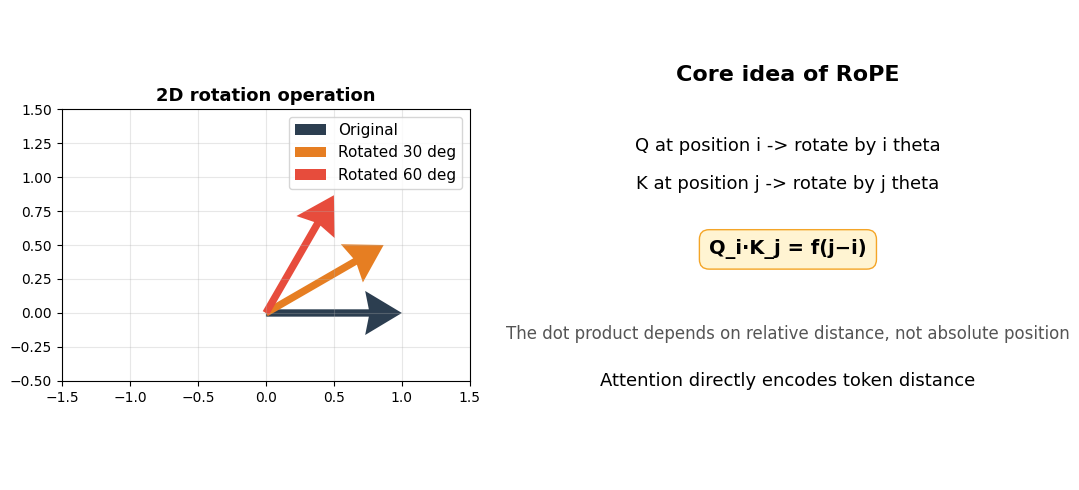

In [10]:
# === 2D 旋转：RoPE 的数学直觉 ===
import matplotlib.pyplot as plt

import torch
import math

print("=== 2D 旋转：为什么旋转能编码相对位置 ===")
print()

# 一个二维向量
v = torch.tensor([1.0, 0.0])

# 旋转矩阵
def rot_matrix(theta):
    """逆时针旋转 theta 弧度"""
    return torch.tensor([
        [math.cos(theta), -math.sin(theta)],
        [math.sin(theta),  math.cos(theta)],
    ])

# 旋转 30° 和 60°
theta_30 = math.radians(30)
theta_60 = math.radians(60)
R30, R60 = rot_matrix(theta_30), rot_matrix(theta_60)
v_30, v_60 = R30 @ v, R60 @ v

print(f"原始向量 v:     ({v[0]:.1f}, {v[1]:.1f}), 角度=0°")
print(f"旋转 30° 后:    ({v_30[0]:.3f}, {v_30[1]:.3f})")
print(f"旋转 60° 后:    ({v_60[0]:.3f}, {v_60[1]:.3f})")
print()

# 性质 1：保长
print(f"性质 1 — 保长: |v|={v.norm():.4f}, |R30·v|={v_30.norm():.4f}")
print("  旋转不改变向量的长度，只改变方向")

# 性质 2：可加性
v_30_30 = R30 @ (R30 @ v)
print(f"性质 2 — 可加: R(30°)·R(30°) = R(60°)")
print(f"  R30·R30·v = ({v_30_30[0]:.3f}, {v_30_30[1]:.3f})")
print(f"  R60·v     = ({v_60[0]:.3f}, {v_60[1]:.3f})  ← 一致")

# 性质 3（最关键）：内积只依赖旋转角度差
# (R(θ₁)u) · (R(θ₂)v) = u · R(θ₂-θ₁)v
u = torch.tensor([0.8, 0.6])
v2 = torch.tensor([0.3, 0.95])
dot_30_60 = (R30 @ u).dot(R60 @ v2)
dot_diff = u.dot(rot_matrix(theta_60 - theta_30) @ v2)
print(f"性质 3 — 相对性（RoPE 依赖的核心性质）:")
print(f"  (R30·u)·(R60·v)     = {dot_30_60:.6f}")
print(f"  u·R(60°-30°)·v      = {dot_diff:.6f}  ← 只依赖角度差 30°")
print()
print("→ 旋转后向量的内积 = 原始向量的内积按角度差旋转")
print("→ 这意味着 Q_i·K_j 只依赖 (j-i)，不依赖 i 和 j 各自的绝对值")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# 左：旋转演示
for theta_deg, color, label in [(0, '#2c3e50', 'Original'),
                                 (30, '#e67e22', 'Rotated 30 deg'),
                                 (60, '#e74c3c', 'Rotated 60 deg')]:
    theta = math.radians(theta_deg)
    R = rot_matrix(theta)
    rotated = R @ v
    axes[0].quiver(0, 0, rotated[0].item(), rotated[1].item(), angles='xy',
                   scale_units='xy', scale=1, color=color, label=label,
                   width=0.018, headwidth=6)
axes[0].set_xlim(-1.5, 1.5); axes[0].set_ylim(-0.5, 1.5)
axes[0].set_aspect('equal'); axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11); axes[0].set_title('2D rotation operation', fontsize=13, fontweight='bold')

# 右：旋转如何编码位置
axes[1].set_xlim(0, 10); axes[1].set_ylim(0, 10)
axes[1].axis('off')
axes[1].text(5, 8.5, 'Core idea of RoPE', ha='center', fontsize=16, fontweight='bold')
axes[1].text(5, 7.0, 'Q at position i -> rotate by i theta', ha='center', fontsize=13)
axes[1].text(5, 6.2, 'K at position j -> rotate by j theta', ha='center', fontsize=13)
axes[1].text(5, 4.8, 'Q_i·K_j = f(j−i)', ha='center', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff3cd', edgecolor='#f39c12', alpha=0.9))
axes[1].text(5, 3.0, 'The dot product depends on relative distance, not absolute position', ha='center', fontsize=12, color='#555')
axes[1].text(5, 2.0, 'Attention directly encodes token distance', ha='center', fontsize=13)

plt.tight_layout()
plt.show()


**从 2D 到高维**

2D 旋转只处理二维向量。但 Q 和 K 通常有 64~128 维。RoPE 的做法是把维度两两配对，每一对独立做 2D 旋转，但每对使用不同的旋转频率：

```
维度对 0 (dim 0, 1):  旋转角 = pos / (10000^(0/d))
维度对 1 (dim 2, 3):  旋转角 = pos / (10000^(2/d))
维度对 2 (dim 4, 5):  旋转角 = pos / (10000^(4/d))
...
```

低维对旋转快（高频——善于区分相邻位置），高维对旋转慢（低频——传递远距离关系）。频率设计和正弦编码的 10000^(2i/d) 完全一致，区别在于正弦编码把频率用在 sin/cos 的参数里（生成位置向量），RoPE 把频率用在旋转角上（旋转 Q 和 K）。

**RoPE 与正弦编码对比**

| | 正弦编码 | RoPE |
|:---|:---|:---|
| 位置信息注入点 | 输入层（加到 Token Embedding 上） | Attention 内部（旋转 Q 和 K） |
| Attention 中的位置项 | Q·K 里混着 PE_i·PE_j 交叉项 | Q_i·K_j 天然编码相对距离 |
| 相对位置感知 | 模型需要学习从绝对位置推断 | 直接写在旋转角度差里 |
| 外推能力 | 可以计算训练外位置，但质量不保证 | 可以计算训练外位置，但直接外推可能退化 |

接下来实现 RoPE 并做实验对比。

In [11]:
# === RoPE 完整实现 ===

import torch

def precompute_rope_freqs(dim, seq_len, theta=10000.0):
    """
    预计算每个位置、每个维度对的 cos 和 sin

    返回:
        cos: [seq_len, dim//2] — cos(pos × θ_k)，θ_k = 1/(theta^(2k/dim))
        sin: [seq_len, dim//2] — sin(pos × θ_k)
    """
    freqs = 1.0 / (theta ** (torch.arange(0, dim, 2).float() / dim))
    positions = torch.arange(seq_len).float()
    angles = torch.outer(positions, freqs)  # [seq_len, dim//2]
    return angles.cos(), angles.sin()

def apply_rotary_emb(x, cos, sin):
    """
    对 x 施加旋转位置编码

    把 x 的最后一维两两分组，每组做 2D 旋转：
        [x0, x1] → [x0×cos - x1×sin, x1×cos + x0×sin]

    参数:
        x: [..., seq_len, d_head] — Q 或 K 的张量
        cos, sin: [seq_len, d_head//2]
    返回:
        旋转后的张量，形状不变
    """
    d = x.shape[-1]
    x_reshaped = x.float().reshape(*x.shape[:-1], -1, 2)
    x1, x2 = x_reshaped[..., 0], x_reshaped[..., 1]

    # cos/sin 对齐到 x 的前导维度
    cos = cos.unsqueeze(0)
    sin = sin.unsqueeze(0)

    # 2D 旋转
    rot1 = x1 * cos - x2 * sin
    rot2 = x2 * cos + x1 * sin

    rotated = torch.stack([rot1, rot2], dim=-1).flatten(-2)
    return rotated.type_as(x)

# === 手算测试：d_head=4 的极小例子 ===
print("=== RoPE 手算：d_head=4 ===")
print()

d_head = 4
seq_len = 3

# 三个位置用相同的向量，方便观察旋转效果
q = torch.tensor([[[1.0, 0.0, 0.5, 0.5],
                    [1.0, 0.0, 0.5, 0.5],
                    [1.0, 0.0, 0.5, 0.5]]])
print(f"原始 Q（三个位置的向量相同）:")
for p in range(seq_len):
    print(f"  位置 {p}: {[f'{v:.1f}' for v in q[0, p].tolist()]}")

# 计算 RoPE cos/sin
cos, sin = precompute_rope_freqs(d_head, seq_len, theta=10000.0)
print(f"\ncos 矩阵 [{cos.shape[0]}位置 × {cos.shape[1]}维度对]:")
print(cos)
print(f"\nsin 矩阵 [{sin.shape[0]}位置 × {sin.shape[1]}维度对]:")
print(sin)

# 应用 RoPE
q_rope = apply_rotary_emb(q, cos, sin)
print(f"\nRoPE 之后的 Q:")
for p in range(seq_len):
    vals = [f'{v:+.4f}' for v in q_rope[0, p].tolist()]
    print(f"  位置 {p}: {vals}")

# 验证关键性质：相同向量旋转后，内积随距离衰减
print(f"\n验证「内积只依赖相对距离」:")
dist_01 = (q_rope[0, 0] * q_rope[0, 1]).sum().item()
dist_02 = (q_rope[0, 0] * q_rope[0, 2]).sum().item()
dist_12 = (q_rope[0, 1] * q_rope[0, 2]).sum().item()
print(f"  距离 1 (位置 0 vs 1): {dist_01:.4f}")
print(f"  距离 2 (位置 0 vs 2): {dist_02:.4f}")
print(f"  距离 1 (位置 1 vs 2): {dist_12:.4f}")
print(f"  → 距离相同 → 内积相近；距离越大 → 内积越小")
print(f"  → 这就是 RoPE 让 Attention 天然感知距离的机制")


=== RoPE 手算：d_head=4 ===

原始 Q（三个位置的向量相同）:
  位置 0: ['1.0', '0.0', '0.5', '0.5']
  位置 1: ['1.0', '0.0', '0.5', '0.5']
  位置 2: ['1.0', '0.0', '0.5', '0.5']

cos 矩阵 [3位置 × 2维度对]:
tensor([[ 1.0000,  1.0000],
        [ 0.5403,  0.9999],
        [-0.4161,  0.9998]])

sin 矩阵 [3位置 × 2维度对]:
tensor([[0.0000, 0.0000],
        [0.8415, 0.0100],
        [0.9093, 0.0200]])

RoPE 之后的 Q:
  位置 0: ['+1.0000', '+0.0000', '+0.5000', '+0.5000']
  位置 1: ['+0.5403', '+0.8415', '+0.4950', '+0.5050']
  位置 2: ['-0.4161', '+0.9093', '+0.4899', '+0.5099']

验证「内积只依赖相对距离」:
  距离 1 (位置 0 vs 1): 1.0403
  距离 2 (位置 0 vs 2): 0.0838
  距离 1 (位置 1 vs 2): 1.0403
  → 距离相同 → 内积相近；距离越大 → 内积越小
  → 这就是 RoPE 让 Attention 天然感知距离的机制


**实验对比**

下面用一个受控实验来对比三种注意力模式。实验设计：所有 token 使用几乎相同的向量（让 token 内容不影响 Attention），这样 Attention 分数的差异完全来自位置编码方式。

对比三种方案：
- **无位置编码**：Q 和 K 不携带任何位置信息
- **正弦位置编码**：PE 加到输入上，再投影成 Q 和 K（前面 的方式）
- **RoPE**：投影后的 Q 和 K 直接做旋转

观察每种方案的 Attention 矩阵，看看位置信息是如何影响 Attention 的。

=== 位置编码对比实验 ===
设计思路：所有 token 向量几乎相同 → Attention 差异纯来自位置编码



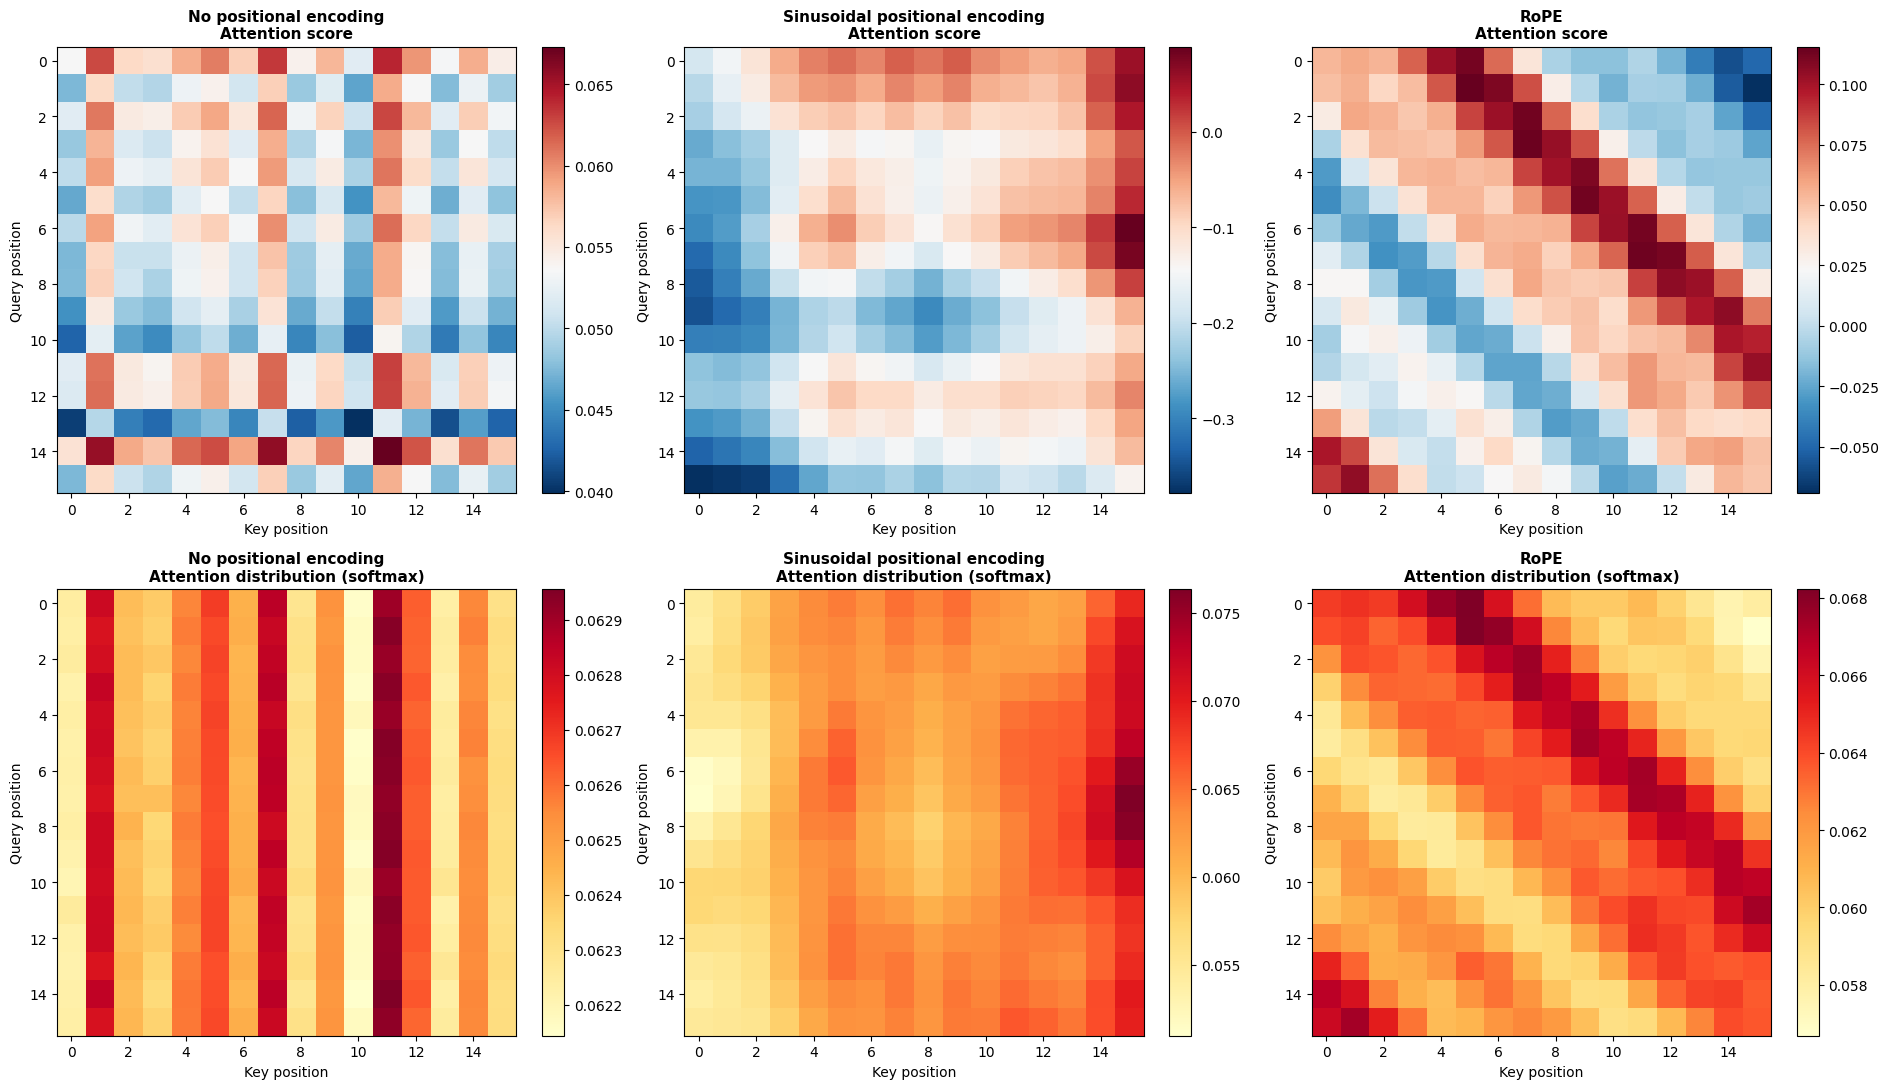


=== Attention 按相对距离的偏好分析 ===


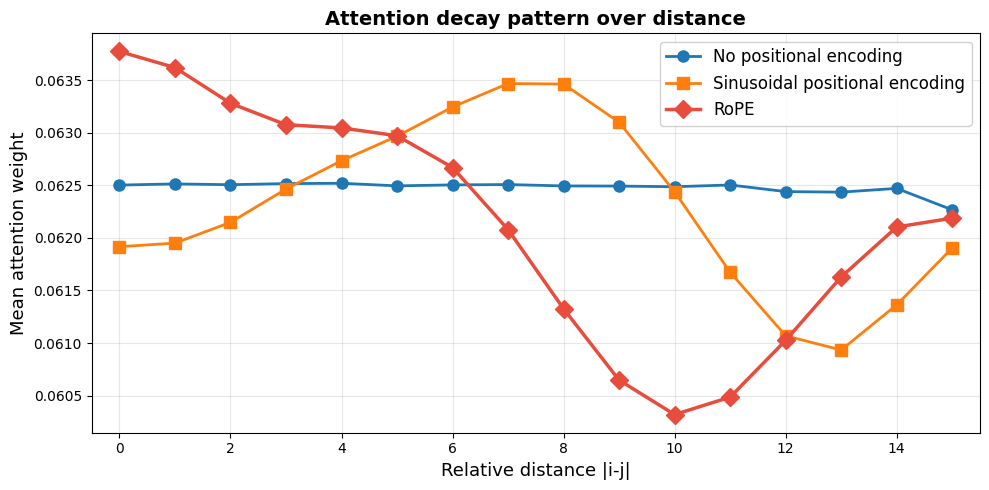


关键观察（结合热力图 + 距离曲线一并看）:

  1. 无位置编码:
     → Attention 接近均匀：距离 0 权重 0.063
       距离 15 权重 0.062
     → 因为所有 token 内容几乎相同，模型没有位置线索

  2. 正弦位置编码:
     → 距离 0 权重 0.062
       距离 15 权重 0.062
     → 位置信息是加到输入上的，Q·K 里会混入位置相关项
     → 模型仍要学习如何从这些项里读出相对距离

  3. RoPE:
     → 距离 0 权重 0.064
       距离 15 权重 0.062
     → 这个随机小实验不保证单调衰减，也不保证某种固定图案
     → 它想展示的是机制：同一相对距离对应相同的旋转角差

RoPE 的核心优势：
  不是强行让 Attention 按距离衰减，而是把相对位置信息
  直接写进 Q 和 K 的内积结构里，减少模型自己学习距离映射的负担


In [12]:
# === 实验：对比三种位置编码的 Attention 模式 ===
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math

print("=== 位置编码对比实验 ===")
print("设计思路：所有 token 向量几乎相同 → Attention 差异纯来自位置编码")
print()

# 实验参数
seq_len = 16
d_model = 32
d_head = 32

# 所有 token 用几乎相同的向量
torch.manual_seed(42)
token_vec = torch.randn(1, d_model) * 0.5
x = token_vec.repeat(1, seq_len, 1)  # [1, 16, 32]
x = x + torch.randn(1, seq_len, d_model) * 0.03  # 微小噪声避免奇异

# 复用 前面 的正弦编码函数
def get_sinusoidal_encoding(seq_len, d_model):
    """正弦位置编码（来自 前面）"""
    position = torch.arange(seq_len).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
    )
    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

# Q/K 投影（三种方案共用，保证公平对比）
W_q = nn.Linear(d_model, d_head, bias=False)
W_k = nn.Linear(d_model, d_head, bias=False)
nn.init.xavier_normal_(W_q.weight, gain=0.5)
nn.init.xavier_normal_(W_k.weight, gain=0.5)

def compute_attention_maps(x_input):
    """
    计算三种 Attention 分数矩阵

    返回: (无PE_scores, 无PE_attn, 正弦_scores, 正弦_attn, RoPE_scores, RoPE_attn)
    """
    # === 方案 1：无位置编码 ===
    q_raw = W_q(x_input)
    k_raw = W_k(x_input)
    scores_no = (q_raw @ k_raw.transpose(-2, -1)) / math.sqrt(d_head)
    attn_no = F.softmax(scores_no, dim=-1)

    # === 方案 2：正弦编码（加到输入上）===
    pe = get_sinusoidal_encoding(seq_len, d_model).unsqueeze(0)
    x_sin = x_input + pe
    q_sin = W_q(x_sin)
    k_sin = W_k(x_sin)
    scores_sin = (q_sin @ k_sin.transpose(-2, -1)) / math.sqrt(d_head)
    attn_sin = F.softmax(scores_sin, dim=-1)

    # === 方案 3：RoPE（旋转 Q 和 K）===
    q_rope = W_q(x_input)
    k_rope = W_k(x_input)
    cos, sin = precompute_rope_freqs(d_head, seq_len)
    q_rope = apply_rotary_emb(q_rope, cos, sin)
    k_rope = apply_rotary_emb(k_rope, cos, sin)
    scores_rope = (q_rope @ k_rope.transpose(-2, -1)) / math.sqrt(d_head)
    attn_rope = F.softmax(scores_rope, dim=-1)

    return (scores_no, attn_no, scores_sin, attn_sin, scores_rope, attn_rope)

scores_no, attn_no, scores_sin, attn_sin, scores_rope, attn_rope = compute_attention_maps(x)

# === 可视化：三列 × 两行 ===
fig, axes = plt.subplots(2, 3, figsize=(19, 11))

titles_score = ['No positional encoding\nAttention score',
                'Sinusoidal positional encoding\nAttention score',
                'RoPE\nAttention score']
titles_attn = ['No positional encoding\nAttention distribution (softmax)',
               'Sinusoidal positional encoding\nAttention distribution (softmax)',
               'RoPE\nAttention distribution (softmax)']

for col, (t_s, t_a, s_mat, a_mat) in enumerate(zip(
    titles_score, titles_attn,
    [scores_no, scores_sin, scores_rope],
    [attn_no, attn_sin, attn_rope]
)):
    # 第一行：Score
    im0 = axes[0, col].imshow(s_mat[0].detach().numpy(), cmap='RdBu_r', aspect='auto')
    axes[0, col].set_title(t_s, fontsize=11, fontweight='bold')
    axes[0, col].set_xlabel('Key position'); axes[0, col].set_ylabel('Query position')
    plt.colorbar(im0, ax=axes[0, col], fraction=0.046)

    # 第二行：Attention
    im1 = axes[1, col].imshow(a_mat[0].detach().numpy(), cmap='YlOrRd', aspect='auto')
    axes[1, col].set_title(t_a, fontsize=11, fontweight='bold')
    axes[1, col].set_xlabel('Key position'); axes[1, col].set_ylabel('Query position')
    plt.colorbar(im1, ax=axes[1, col], fraction=0.046)

plt.tight_layout()
plt.show()

# === 提取 Attention 的「距离偏好」曲线 ===
print()
print("=== Attention 按相对距离的偏好分析 ===")

def distance_profile(attn_mat):
    """计算 attention 按 |i-j| 的平均值"""
    seq_len = attn_mat.shape[0]
    dists = {}
    for i in range(seq_len):
        for j in range(seq_len):
            d = abs(i - j)
            dists.setdefault(d, []).append(attn_mat[i, j].item())
    return [sum(dists[d]) / len(dists[d]) for d in sorted(dists)]

decay_no = distance_profile(attn_no[0])
decay_sin = distance_profile(attn_sin[0])
decay_rope = distance_profile(attn_rope[0])

fig, ax = plt.subplots(figsize=(10, 5))
dists = range(len(decay_no))
ax.plot(dists, decay_no, 'o-', label='No positional encoding', linewidth=2, markersize=8)
ax.plot(dists, decay_sin, 's-', label='Sinusoidal positional encoding', linewidth=2, markersize=8)
ax.plot(dists, decay_rope, 'D-', label='RoPE', linewidth=2.5, markersize=9,
        color='#e74c3c')
ax.set_xlabel('Relative distance |i-j|', fontsize=13)
ax.set_ylabel('Mean attention weight', fontsize=13)
ax.set_title('Attention decay pattern over distance', fontsize=14, fontweight='bold')
ax.legend(fontsize=12, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.5, len(dists) - 0.5)
plt.tight_layout()
plt.show()

# === 关键观察 ===
print()
print("关键观察（结合热力图 + 距离曲线一并看）:")
print()
print("  1. 无位置编码:")
print(f"     → Attention 接近均匀：距离 0 权重 {decay_no[0]:.3f}")
print(f"       距离 15 权重 {decay_no[-1]:.3f}")
print("     → 因为所有 token 内容几乎相同，模型没有位置线索")
print()
print("  2. 正弦位置编码:")
print(f"     → 距离 0 权重 {decay_sin[0]:.3f}")
print(f"       距离 15 权重 {decay_sin[-1]:.3f}")
print("     → 位置信息是加到输入上的，Q·K 里会混入位置相关项")
print("     → 模型仍要学习如何从这些项里读出相对距离")
print()
print("  3. RoPE:")
print(f"     → 距离 0 权重 {decay_rope[0]:.3f}")
print(f"       距离 15 权重 {decay_rope[-1]:.3f}")
print("     → 这个随机小实验不保证单调衰减，也不保证某种固定图案")
print("     → 它想展示的是机制：同一相对距离对应相同的旋转角差")
print()
print("RoPE 的核心优势：")
print("  不是强行让 Attention 按距离衰减，而是把相对位置信息")
print("  直接写进 Q 和 K 的内积结构里，减少模型自己学习距离映射的负担")


## 现代 LLaMA-style Block

四个改进全部到位，把它们一次组装：

```
LLaMA Block = Pre-Norm (RMSNorm) + RoPE Attention + Pre-Norm (RMSNorm) + SwiGLU FFN

  x
  │
  ├─→ RMSNorm → RoPE Attention ─→ +  ← 残差（不经过 Norm！）
  │                                │
  ├────────────────────────────────┘
  │
  ├─→ RMSNorm → SwiGLU FFN ─→ +  ← 残差（不经过 Norm！）
  │                             │
  └─────────────────────────────┘
  ↓
 输出
```

In [13]:
import torch
import torch.nn as nn

class LLaMABlock(nn.Module):
    """
    现代 LLM 的 Transformer Block

    三大升级 vs 前面:
    1. LayerNorm → RMSNorm
    2. Post-Norm → Pre-Norm
    3. ReLU FFN → SwiGLU FFN
    """
    def __init__(self, d_model, num_heads, d_ff=None):
        super().__init__()
        # Pre-Norm: RMSNorm 在 Attention 前面
        self.norm_attn = RMSNorm(d_model)
        # Multi-Head Self-Attention（和 前面 一样）
        self.attention = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        # Pre-Norm: RMSNorm 在 FFN 前面
        self.norm_ffn = RMSNorm(d_model)
        # SwiGLU FFN
        self.ffn = FeedForward_SwiGLU(d_model, d_ff)

    def forward(self, x, mask=None):
        # 注意顺序：先 Norm，再子层，再残差
        h = self.norm_attn(x)
        attn_out, _ = self.attention(h, h, h, attn_mask=mask, need_weights=False)
        x = x + attn_out  # 残差：绕过 Norm！

        h = self.norm_ffn(x)
        x = x + self.ffn(h)  # 残差：绕过 Norm！

        return x

# 测试
d_model, num_heads = 8, 2
block_new = LLaMABlock(d_model, num_heads)

test_x = torch.randn(1, 5, d_model)
causal_mask = torch.triu(torch.ones(5, 5) * float('-inf'), diagonal=1)

out_new = block_new(test_x, causal_mask)
print("=== LLaMA Block 测试 ===")
print(f"输入形状: {test_x.shape}")
print(f"输出形状: {out_new.shape}  ← 不变！")
print(f"但里面的组件全部升级了:")
print(f"  ✓ RMSNorm 替代 LayerNorm")
print(f"  ✓ Pre-Norm 替代 Post-Norm")
print(f"  ✓ SwiGLU 替代 ReLU FFN")


=== LLaMA Block 测试 ===
输入形状: torch.Size([1, 5, 8])
输出形状: torch.Size([1, 5, 8])  ← 不变！
但里面的组件全部升级了:
  ✓ RMSNorm 替代 LayerNorm
  ✓ Pre-Norm 替代 Post-Norm
  ✓ SwiGLU 替代 ReLU FFN


## 多头注意力

前面四处升级都在 Block 内部，没动 Attention 的多头结构。但多头 Attention 在推理时有个工程瓶颈：每个 head 都要缓存自己的 K 和 V（KV Cache），head 越多显存占用越大。这一节看现代 LLM 怎么改 Attention 的多头组织方式来缓解这个问题——从 MHA 到 GQA，再到 DeepSeek 提出的 MLA。

**MHA 与 GQA**

前面四个改进解决了稳定性、效果、效率、位置编码。Attention 还有一个工程问题：多头结构在推理时显存开销大。

每个 head 都要缓存自己的 K 和 V（KV Cache），head 越多显存占用越大。一个 32 头的模型，KV Cache 就是 32 份 K 和 32 份 V。当上下文长度拉到几千甚至几万时，这部分显存很容易成为瓶颈。

GQA（Grouped-Query Attention）的思路是让多个 Q 头共享同一组 K、V，从而缩小 KV Cache。

In [14]:
# === MHA vs GQA vs MQA：KV Cache 手算对比 ===
print("=== KV Cache 对比：MHA / GQA / MQA ===")
print()

# 假设：一个 32 个 Q 头、每头 128 维的 decoder-only 模型
num_q_heads = 32      # Q 的头数
d_head = 128          # 每个头的维度
seq_len = 4096        # 序列长度
dtype_bytes = 2       # bf16 占 2 字节

# 三种方案的 KV 头数
configs = [
    ("MHA", num_q_heads, num_q_heads),
    ("GQA-4", 4, num_q_heads),
    ("GQA-8", 8, num_q_heads),
    ("MQA", 1, num_q_heads),
]

print(f"模型配置: {num_q_heads} 个 Q 头, 每头 {d_head} 维")
print(f"序列长度: {seq_len}, 数据类型: bf16 (2 bytes)")
print()

mha_size = None

for name, kv_heads, _ in configs:
    # KV Cache 大小 = 2(K+V) × kv_heads × d_head × seq_len × dtype_bytes
    kv_size = 2 * kv_heads * d_head * seq_len * dtype_bytes
    kv_size_mb = kv_size / (1024 ** 2)
    
    if mha_size is None:
        mha_size = kv_size
    ratio = kv_size / mha_size * 100
    
    # 每组多少个 Q 头
    q_per_group = num_q_heads // kv_heads
    
    print(f"{name:<8s} KV头数={kv_heads:>2d}  "
          f"每组Q头={q_per_group:>2d}  "
          f"KV Cache={kv_size_mb:>6.1f} MB  "
          f"({ratio:>5.1f}%)")

print()
print("关键数字：")
print(f"  MHA:   {2 * num_q_heads * d_head * seq_len * dtype_bytes / (1024**2):.0f} MB（32 个 KV 头）")
print(f"  GQA-4: {2 * 4 * d_head * seq_len * dtype_bytes / (1024**2):.0f} MB（4 个 KV 头，省 87.5%）")
print(f"  MQA:   {2 * 1 * d_head * seq_len * dtype_bytes / (1024**2):.0f} MB（1 个 KV 头，省 97%）")
print()
print("现实例子：LLaMA 2 70B 使用 GQA；Mistral 7B、LLaMA 3 也使用 GQA")
print("注意：LLaMA 2 的 7B/13B 版本不是这个例子，不要把型号混在一起")
print("直觉：KV 头数减少多少倍，KV Cache 大致就减少多少倍")

=== KV Cache 对比：MHA / GQA / MQA ===

模型配置: 32 个 Q 头, 每头 128 维
序列长度: 4096, 数据类型: bf16 (2 bytes)

MHA      KV头数=32  每组Q头= 1  KV Cache=  64.0 MB  (100.0%)
GQA-4    KV头数= 4  每组Q头= 8  KV Cache=   8.0 MB  ( 12.5%)
GQA-8    KV头数= 8  每组Q头= 4  KV Cache=  16.0 MB  ( 25.0%)
MQA      KV头数= 1  每组Q头=32  KV Cache=   2.0 MB  (  3.1%)

关键数字：
  MHA:   64 MB（32 个 KV 头）
  GQA-4: 8 MB（4 个 KV 头，省 87.5%）
  MQA:   2 MB（1 个 KV 头，省 97%）

现实例子：LLaMA 2 70B 使用 GQA；Mistral 7B、LLaMA 3 也使用 GQA
注意：LLaMA 2 的 7B/13B 版本不是这个例子，不要把型号混在一起
直觉：KV 头数减少多少倍，KV Cache 大致就减少多少倍


**GQA 实现**

GQA 和 MHA 的区别只在一步：把 Q 按「组」切分，每组内的 Q 头共享同一组 K 和 V。

```
MHA:  Q [32, d] × K [32, d] → 32 组独立的 attention
GQA:  Q [32, d] × K [4, d]  → 32 个 Q 分成 4 组，每组 8 个 Q 共享 1 个 K

实现方式：
  1. K/V 只有 4 个头，通过 repeat 扩展到 32 个头
  2. 然后和 MHA 完全一样做 attention
```

所以 GQA 的代码改动极小——只需在 K、V 上多做一次 `expand`。

In [15]:
# === GQA 实现演示 ===

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class GroupedQueryAttention(nn.Module):
    """
    Grouped-Query Attention (GQA)

    参数:
        d_model: 模型维度
        num_q_heads: Q 的头数（如 32）
        num_kv_heads: K/V 的头数（如 4），必须能整除 num_q_heads
    """
    def __init__(self, d_model, num_q_heads, num_kv_heads):
        super().__init__()
        assert num_q_heads % num_kv_heads == 0

        self.num_q_heads = num_q_heads
        self.num_kv_heads = num_kv_heads
        self.d_head = d_model // num_q_heads
        self.q_per_group = num_q_heads // num_kv_heads  # 每组几个 Q 头

        # Q 有 num_q_heads 个头，K/V 只有 num_kv_heads 个头
        self.W_q = nn.Linear(d_model, num_q_heads * self.d_head, bias=False)
        self.W_k = nn.Linear(d_model, num_kv_heads * self.d_head, bias=False)
        self.W_v = nn.Linear(d_model, num_kv_heads * self.d_head, bias=False)
        self.W_o = nn.Linear(num_q_heads * self.d_head, d_model, bias=False)

    def forward(self, x, mask=None):
        B, S, D = x.shape

        # 投影
        q = self.W_q(x)  # [B, S, num_q * d_head]
        k = self.W_k(x)  # [B, S, num_kv * d_head]
        v = self.W_v(x)  # [B, S, num_kv * d_head]

        # reshape 成多头形式
        q = q.view(B, S, self.num_q_heads, self.d_head)
        k = k.view(B, S, self.num_kv_heads, self.d_head)
        v = v.view(B, S, self.num_kv_heads, self.d_head)

        # GQA 关键一步：把 K/V 扩展到和 Q 一样的头数
        # 每个 KV 头被 self.q_per_group 个 Q 头共享
        k = k[:, :, None, :, :].expand(
            B, S, self.q_per_group, self.num_kv_heads, self.d_head
        ).reshape(B, S, self.num_q_heads, self.d_head)

        v = v[:, :, None, :, :].expand(
            B, S, self.q_per_group, self.num_kv_heads, self.d_head
        ).reshape(B, S, self.num_q_heads, self.d_head)

        # 转成 [B, heads, S, d_head] 做 attention
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        # 缩放点积 attention（和前面一样）
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_head)
        if mask is not None:
            scores = scores + mask
        attn = F.softmax(scores, dim=-1)
        out = torch.matmul(attn, v)

        # 合并头，输出投影
        out = out.transpose(1, 2).contiguous().view(B, S, -1)
        return self.W_o(out)

# 测试：对比 MHA 和 GQA
d_model = 256
num_q = 8    # 8 个 Q 头
num_kv = 2   # 2 个 KV 头 → 每组 4 个 Q 共享 1 个 KV

gqa = GroupedQueryAttention(d_model, num_q, num_kv)
mha = nn.MultiheadAttention(d_model, num_q, batch_first=True)

x = torch.randn(1, 6, d_model)
mask = torch.triu(torch.ones(6, 6) * float('-inf'), diagonal=1)

out_gqa = gqa(x, mask)
out_mha, _ = mha(x, x, x, attn_mask=mask, need_weights=False)

print("=== GQA 实现 ===")
print(f"输入: {x.shape}")
print(f"GQA 输出: {out_gqa.shape}")
print(f"MHA 输出: {out_mha.shape}")
print()

# 参数量对比
gqa_params = sum(p.numel() for p in gqa.parameters())
mha_params = sum(p.numel() for p in mha.parameters())
print(f"GQA 参数: {gqa_params:,}  (KV 投影更小)")
print(f"MHA 参数: {mha_params:,}")
print(f"GQA 参数是 MHA 的 {gqa_params/mha_params:.2%}")
print()
print(f"KV 投影对比:")
print(f"  MHA: W_k {d_model}×{d_model} = {d_model*d_model:,}")
print(f"  GQA: W_k {d_model}×{num_kv * (d_model//num_q)} = {d_model * num_kv * (d_model//num_q):,}")
print(f"  → GQA 的 KV 投影只有 MHA 的 {num_kv/num_q:.0%}")


=== GQA 实现 ===
输入: torch.Size([1, 6, 256])
GQA 输出: torch.Size([1, 6, 256])
MHA 输出: torch.Size([1, 6, 256])

GQA 参数: 163,840  (KV 投影更小)
MHA 参数: 263,168
GQA 参数是 MHA 的 62.26%

KV 投影对比:
  MHA: W_k 256×256 = 65,536
  GQA: W_k 256×64 = 16,384
  → GQA 的 KV 投影只有 MHA 的 25%


**QK-Norm**

In [16]:
# === QK-Norm 对比：不加 vs 加 ===
import torch
import torch.nn.functional as F
import math

print("=== QK-Norm：模拟 Attention logit 退化问题 ===")
print()

# 模拟训练后期的 Q 和 K：模长差异大
torch.manual_seed(42)
d_head = 8
seq_len = 4

# 正常的 Q
Q_normal = torch.randn(1, 1, seq_len, d_head) * 1.0
# 训练后期 K 的模长变得很大
K_large = torch.randn(1, 1, seq_len, d_head) * 8.0

# 不用 QK-Norm：直接算 attention score
score_no_norm = (Q_normal @ K_large.transpose(-2, -1)) / math.sqrt(d_head)
attn_no_norm = F.softmax(score_no_norm, dim=-1)

# 用 QK-Norm：先各自 RMSNorm
Q_normed = Q_normal / torch.sqrt(torch.mean(Q_normal ** 2, dim=-1, keepdim=True) + 1e-6)
K_normed = K_large / torch.sqrt(torch.mean(K_large ** 2, dim=-1, keepdim=True) + 1e-6)
score_with_norm = (Q_normed @ K_normed.transpose(-2, -1)) / math.sqrt(d_head)
attn_with_norm = F.softmax(score_with_norm, dim=-1)

print("不加 QK-Norm:")
print(f"  Q 模长范围: {Q_normal.norm(dim=-1).min():.2f} ~ {Q_normal.norm(dim=-1).max():.2f}")
print(f"  K 模长范围: {K_large.norm(dim=-1).min():.2f} ~ {K_large.norm(dim=-1).max():.2f}")
print(f"  Attention score: {score_no_norm[0,0,0].tolist()}")
print(f"  Attention 分布:  {[f'{v:.3f}' for v in attn_no_norm[0,0,0].tolist()]}")
print(f"  → softmax 退化：大部分概率集中在个别位置")

print()
print("加 QK-Norm:")
print(f"  Q 模长范围: {Q_normed.norm(dim=-1).min():.2f} ~ {Q_normed.norm(dim=-1).max():.2f}")
print(f"  K 模长范围: {K_normed.norm(dim=-1).min():.2f} ~ {K_normed.norm(dim=-1).max():.2f}")
print(f"  Attention score: {score_with_norm[0,0,0].tolist()}")
print(f"  Attention 分布:  {[f'{v:.3f}' for v in attn_with_norm[0,0,0].tolist()]}")
print(f"  → 分布不再极端集中，Attention 更容易聚合多个位置")

print()
print("关键观察：QK-Norm 把 Q、K 模长都拉到 ≈ 1，")
print("score 的尺度被显著收窄，softmax 不再那么容易退化。")


=== QK-Norm：模拟 Attention logit 退化问题 ===

不加 QK-Norm:
  Q 模长范围: 2.52 ~ 3.97
  K 模长范围: 16.80 ~ 28.22
  Attention score: [-16.435527801513672, -10.454450607299805, -12.33845043182373, -24.44552230834961]
  Attention 分布:  ['0.002', '0.866', '0.132', '0.000']
  → softmax 退化：大部分概率集中在个别位置

加 QK-Norm:
  Q 模长范围: 2.83 ~ 2.83
  K 模长范围: 2.83 ~ 2.83
  Attention score: [-1.6068212985992432, -0.7471929788589478, -1.4809514284133911, -2.0364327430725098]
  Attention 分布:  ['0.194', '0.459', '0.220', '0.126']
  → 分布不再极端集中，Attention 更容易聚合多个位置

关键观察：QK-Norm 把 Q、K 模长都拉到 ≈ 1，
score 的尺度被显著收窄，softmax 不再那么容易退化。


In [17]:
# === 带 QK-Norm 的 GQA 完整实现 ===

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class GroupedQueryAttention_QKNorm(nn.Module):
    """
    GQA + QK-Norm（展示一种稳定 attention logits 的技巧）

    相比标准 GQA，只多了两行 RMSNorm：一行给 Q，一行给 K。
    """
    def __init__(self, d_model, num_q_heads, num_kv_heads, eps=1e-6):
        super().__init__()
        assert num_q_heads % num_kv_heads == 0

        self.num_q_heads = num_q_heads
        self.num_kv_heads = num_kv_heads
        self.d_head = d_model // num_q_heads
        self.q_per_group = num_q_heads // num_kv_heads

        self.W_q = nn.Linear(d_model, num_q_heads * self.d_head, bias=False)
        self.W_k = nn.Linear(d_model, num_kv_heads * self.d_head, bias=False)
        self.W_v = nn.Linear(d_model, num_kv_heads * self.d_head, bias=False)
        self.W_o = nn.Linear(num_q_heads * self.d_head, d_model, bias=False)

        # QK-Norm：对 Q 和 K 各自做 RMSNorm
        self.q_norm = RMSNorm(self.d_head, eps=eps)
        self.k_norm = RMSNorm(self.d_head, eps=eps)

    def forward(self, x, mask=None):
        B, S, D = x.shape

        q = self.W_q(x).view(B, S, self.num_q_heads, self.d_head)
        k = self.W_k(x).view(B, S, self.num_kv_heads, self.d_head)
        v = self.W_v(x).view(B, S, self.num_kv_heads, self.d_head)

        # QK-Norm：在算 attention 之前，各自做 RMSNorm
        q = self.q_norm(q)
        k = self.k_norm(k)

        # GQA expand
        k = k[:, :, None, :, :].expand(
            B, S, self.q_per_group, self.num_kv_heads, self.d_head
        ).reshape(B, S, self.num_q_heads, self.d_head)
        v = v[:, :, None, :, :].expand(
            B, S, self.q_per_group, self.num_kv_heads, self.d_head
        ).reshape(B, S, self.num_q_heads, self.d_head)

        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_head)
        if mask is not None:
            scores = scores + mask
        attn = F.softmax(scores, dim=-1)
        out = torch.matmul(attn, v)

        out = out.transpose(1, 2).contiguous().view(B, S, -1)
        return self.W_o(out)

# 测试
d_model, num_q, num_kv = 16, 4, 2
attn_qknorm = GroupedQueryAttention_QKNorm(d_model, num_q, num_kv)
x = torch.randn(1, 6, d_model)
mask = torch.triu(torch.ones(6, 6) * float('-inf'), diagonal=1)
out = attn_qknorm(x, mask)

print("=== GQA + QK-Norm 测试 ===")
print(f"输入: {x.shape}, 输出: {out.shape}")
print(f"Q heads: {num_q}, KV heads: {num_kv}")
print(f"改动：比标准 GQA 多了 self.q_norm 和 self.k_norm 两行")
print("效果：Q、K 的尺度更受控，attention logits 不容易异常变大")


=== GQA + QK-Norm 测试 ===
输入: torch.Size([1, 6, 16]), 输出: torch.Size([1, 6, 16])
Q heads: 4, KV heads: 2
改动：比标准 GQA 多了 self.q_norm 和 self.k_norm 两行
效果：Q、K 的尺度更受控，attention logits 不容易异常变大


**MLA 极致压缩**

In [18]:
# === MHA vs GQA vs MLA：KV Cache 缓存对比 ===
print("=== KV Cache 三阶段对比：MHA → GQA → MLA ===")
print()

# 小型模型参数
d_model = 512
num_q_heads = 8
d_head = d_model // num_q_heads  # = 64
d_latent = 64  # MLA 压缩维度（远小于 d_model=512）
seq_len = 4096
dtype_bytes = 2  # bf16

print(f"模型: d_model={d_model}, Q heads={num_q_heads}, d_head={d_head}")
print(f"序列长度: {seq_len}, dtype: bf16")
print(f"MLA latent 维度: {d_latent}")
print()

# MHA: KV Cache = 2 × num_heads × d_head × seq_len × bytes
mha_kv = 2 * num_q_heads * d_head * seq_len * dtype_bytes

# GQA-4: 4 个 KV 头
gqa_kv_heads = 4
gqa_kv = 2 * gqa_kv_heads * d_head * seq_len * dtype_bytes

# GQA-2: 2 个 KV 头
gqa2_kv = 2 * 2 * d_head * seq_len * dtype_bytes

# MLA: 只存压缩后的 latent
mla_kv = d_latent * seq_len * dtype_bytes  # 极简假设：只存 joint latent c_KV

configs = [
    ("MHA", mha_kv),
    ("GQA-4", gqa_kv),
    ("GQA-2", gqa2_kv),
    ("MLA", mla_kv),
]

print(f"{'方案':<10s} {'KV Cache 大小':>16s} {'相对 MHA':>10s} {'说明'}")
print("-" * 65)

for name, size in configs:
    mb = size / (1024**2)
    ratio = size / mha_kv * 100
    note = ""
    if name == "MHA":
        note = "每个 Q 头独立 KV"
    elif name == "GQA-4":
        note = "4 组 Q 共享 KV"
    elif name == "GQA-2":
        note = "2 组 Q 共享 KV，效果开始掉"
    elif name == "MLA":
        note = f"低秩压缩到 {d_latent} 维"
    print(f"{name:<10s} {mb:>13.1f} MB {'(' + str(int(ratio)) + '%)':>11s} {note}")

print()
print("关键数字：")
print(f"  MHA → GQA-4: 省 {(1 - gqa_kv/mha_kv)*100:.0f}%")
print(f"  MHA → MLA:   省 {(1 - mla_kv/mha_kv)*100:.0f}%")
print(f"  GQA-4 → MLA: 省 {(1 - mla_kv/gqa_kv)*100:.0f}%")
print()
print("MLA 的直觉：d_latent << d_model（64 << 512），Cache 可以明显变小")
print("真实 MLA 还要处理 RoPE 解耦等细节；这里先看低秩压缩的核心想法")
print("低秩压缩成立的前提是：K/V 信息里有较多冗余，可以用少量方向近似表示")

=== KV Cache 三阶段对比：MHA → GQA → MLA ===

模型: d_model=512, Q heads=8, d_head=64
序列长度: 4096, dtype: bf16
MLA latent 维度: 64

方案              KV Cache 大小     相对 MHA 说明
-----------------------------------------------------------------
MHA                  8.0 MB      (100%) 每个 Q 头独立 KV
GQA-4                4.0 MB       (50%) 4 组 Q 共享 KV
GQA-2                2.0 MB       (25%) 2 组 Q 共享 KV，效果开始掉
MLA                  0.5 MB        (6%) 低秩压缩到 64 维

关键数字：
  MHA → GQA-4: 省 50%
  MHA → MLA:   省 94%
  GQA-4 → MLA: 省 88%

MLA 的直觉：d_latent << d_model（64 << 512），Cache 可以明显变小
真实 MLA 还要处理 RoPE 解耦等细节；这里先看低秩压缩的核心想法
低秩压缩成立的前提是：K/V 信息里有较多冗余，可以用少量方向近似表示


**MLA 实现**

MLA 和标准 Attention 的区别只在 KV 的来源：

```text
标准: K = W_K @ x,  V = W_V @ x  （直接从 x 投影）
MLA:  c_KV = W_down @ x          （先压缩到一个很小的 latent）
      K = W_up_K @ c_KV          （推理时从 latent 解压出 K）
      V = W_up_V @ c_KV          （推理时从 latent 解压出 V）
```

下面用极简实现展示这个机制。完整的 MLA 还涉及 RoPE 的解耦处理，这里先聚焦核心的低秩压缩思路。


In [19]:
# === MLA 极简实现（展示低秩压缩的核心机制） ===

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class MultiHeadLatentAttention(nn.Module):
    """
    MLA（Multi-head Latent Attention）极简版

    KV 先压缩到 d_latent 维的 latent 空间，
    推理时从 latent 解压出 K 和 V。

    参数:
        d_model: 模型维度
        num_heads: 注意力头数
        d_latent: KV 压缩维度（远小于 d_model）
    """
    def __init__(self, d_model, num_heads, d_latent):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_head = d_model // num_heads
        self.d_latent = d_latent

        # Q 照常投影
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        # KV 先压缩到 latent
        self.W_kv_down = nn.Linear(d_model, d_latent, bias=False)
        # 再从 latent 解压出 K 和 V
        self.W_k_up = nn.Linear(d_latent, d_model, bias=False)
        self.W_v_up = nn.Linear(d_latent, d_model, bias=False)
        # 输出投影
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, mask=None):
        B, S, D = x.shape

        # Q：正常投影
        q = self.W_q(x).view(B, S, self.num_heads, self.d_head)

        # KV：先压缩到 latent，再解压
        c_kv = self.W_kv_down(x)           # [B, S, d_latent]
        k = self.W_k_up(c_kv).view(B, S, self.num_heads, self.d_head)
        v = self.W_v_up(c_kv).view(B, S, self.num_heads, self.d_head)

        # 标准的 scaled dot-product attention
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_head)
        if mask is not None:
            scores = scores + mask
        attn = F.softmax(scores, dim=-1)
        out = torch.matmul(attn, v)

        out = out.transpose(1, 2).contiguous().view(B, S, D)
        return self.W_o(out), c_kv  # 返回 c_kv 就是 KV Cache

# 测试 MLA
d_model = 64
num_heads = 4
d_latent = 16  # 压缩维度：16 << 64

mla = MultiHeadLatentAttention(d_model, num_heads, d_latent)
x = torch.randn(1, 6, d_model)
mask = torch.triu(torch.ones(6, 6) * float('-inf'), diagonal=1)

out, c_kv = mla(x, mask)

print("=== MLA 极简实现测试 ===")
print(f"d_model={d_model}, num_heads={num_heads}, d_latent={d_latent}")
print(f"输入: {x.shape}")
print(f"压缩 latent c_kv: {c_kv.shape}  ← 这就是 KV Cache 的大小")
print(f"输出: {out.shape}")
print()

# KV Cache 对比
mha_kv_per_token = 2 * num_heads * (d_model // num_heads)  # K+V 完整维度
mla_kv_per_token = d_latent  # 只存 latent

print(f"每个 token 的 KV Cache(元素数):")
print(f"  MHA: {mha_kv_per_token} (K+V, {num_heads} 头 × {d_model//num_heads} 维)")
print(f"  MLA: {mla_kv_per_token} (只有 c_kv, {d_latent} 维)")
print(f"  压缩比: {mla_kv_per_token/mha_kv_per_token:.1%}")
print()
print("MLA 的 trade-off：")
print(f"  训练时: 多了 W_kv_down, W_k_up, W_v_up 三个线性层（额外的参数和计算）")
print(f"  推理时: KV Cache 从 {mha_kv_per_token} 降到 {mla_kv_per_token} 个元素")
print(f"  → 同样的显存可以处理 {(mha_kv_per_token/mla_kv_per_token):.0f} 倍长的序列")


=== MLA 极简实现测试 ===
d_model=64, num_heads=4, d_latent=16
输入: torch.Size([1, 6, 64])
压缩 latent c_kv: torch.Size([1, 6, 16])  ← 这就是 KV Cache 的大小
输出: torch.Size([1, 6, 64])

每个 token 的 KV Cache(元素数):
  MHA: 128 (K+V, 4 头 × 16 维)
  MLA: 16 (只有 c_kv, 16 维)
  压缩比: 12.5%

MLA 的 trade-off：
  训练时: 多了 W_kv_down, W_k_up, W_v_up 三个线性层（额外的参数和计算）
  推理时: KV Cache 从 128 降到 16 个元素
  → 同样的显存可以处理 8 倍长的序列


**附录：多路残差连接（mHC）**

前面讲了残差连接的演进：Post-Norm（原始 Transformer）→ Pre-Norm（GPT-2 / LLaMA-style）→ DeepNorm（极深 Transformer）。它们都在解决同一个问题：层数越来越深时，信息和梯度怎么稳定地穿过很多层。

DeepSeek V4 技术预览资料中提到的 mHC（manifold-constrained hyper-connections）属于这一方向的进一步探索。关键词拆成两部分：

- **hyper-connections**：不只依赖一条简单的 residual path，而是让多条信息流之间可以学习如何混合
- **manifold-constrained**：混合矩阵不是完全自由学习，而是受到约束，避免训练中出现信息断流或梯度爆炸

普通残差连接可以写成：

$$x_{l+1} = x_l + f_l(x_l)$$

identity 分支和 residual 分支的比例是固定的。多路残差的直觉是让网络自己学习「这一层应该多保留原信息，还是多做变换」。真实 mHC 的实现比下面的示意复杂得多，但可以先把它想成一组受约束的可学习混合权重：

```text
标准残差：
  一条 identity 分支 + 一条 residual 分支，比例基本固定

mHC 的直觉：
  多条信息流并行传递
  每层学习这些信息流怎么混合
  混合权重受到约束，避免数值失控
```

mHC 不是 Attention 或 FFN 的替代品，而是残差连接的升级版。它和 Pre-Norm、DeepNorm 关注的是同一个问题：深层网络里信息和梯度如何稳定流动。

从残差连接的演进历程来看：

```text
Post-Norm (2017)   残差后归一化，深层训练较难
    ↓
Pre-Norm (2019+)   残差前归一化，深层训练更稳定
    ↓
DeepNorm (2022)    为很深的 Transformer 设计残差缩放
    ↓
mHC (2026 preview) 多路受约束的信息混合，用于探索更深网络
```

这一节不实现 mHC，因为它已经超出从零理解基础组件的范围。先记住一点：它和 Pre-Norm、DeepNorm 一样，关注的核心问题都是「深层网络里的信息和梯度如何稳定流动」。

## 三代 Block 演进

```text
2017  原始 Transformer (Vaswani et al.)
      Post-Norm + LayerNorm + ReLU FFN + 正弦位置编码
      └→ 能跑，但原始论文的 encoder/decoder 都只有 6 层

2019  GPT-2
      Pre-LN 风格 + LayerNorm + GELU FFN + 可学习位置嵌入
      └→ 已经不是原始 Transformer 的 Post-Norm + ReLU 配方

2023  LLaMA-style decoder-only LLM
      Pre-Norm + RMSNorm + SwiGLU FFN + RoPE
      └→ 这组组件后来被许多开源 LLM 采用或改造
```

如果要给四个改进的重要性排序，可以这样理解：
1. **Pre-Norm**：先解决深层训练稳定性
2. **RoPE**：把相对位置信息更直接地放进 Attention
3. **SwiGLU**：用门控机制增强 FFN 表达能力
4. **RMSNorm**：简化归一化计算，常和 Pre-Norm 搭配使用

## 小结

确认你已经搞懂了这些（按顺序检查）：

1. ✅ LayerNorm = (x - μ) / σ × γ + β，算两个统计量
2. ✅ RMSNorm = x / RMS(x) × γ，只算一个统计量——去掉了去均值
3. ✅ RMSNorm 省的计算：不用算 μ，不用算 (x-μ)²（直接用 x²）
4. ✅ 正弦编码加在输入上，RoPE 旋转 Q 和 K——位置信息进入 Attention 的方式不同
5. ✅ RoPE 的核心性质：Q_i·K_j 只依赖相对位置 (j−i)
6. ✅ RoPE 实现：维度两两配对做 2D 旋转，低维高频、高维低频
7. ✅ FFN 是 Block 里的逐 token 加工车间，现代模型会重点升级它
8. ✅ ReLU 的问题：负数直接变 0，负数区梯度也为 0
9. ✅ SwiGLU = 信息通道 (W_up) × 门控通道 (Swish(W_gate))
10. ✅ Swish 平滑且负数区有非零梯度，不像 ReLU 那样一刀切
11. ✅ Post-Norm = 子层+残差→Norm，残差路径经过 Norm
12. ✅ Pre-Norm = Norm→子层→+残差，残差路径绕过 Norm
13. ✅ Pre-Norm 好在哪：残差路径更直接，深层训练通常更稳定
14. ✅ LLaMA-style Block = Pre-Norm + RMSNorm + RoPE + SwiGLU
15. ✅ GQA = 多个 Q 头共享一组 KV 头，KV Cache 大幅缩小
16. ✅ MHA（32 KV 头）→ GQA（4 KV 头，省 87.5%）→ MQA（1 KV 头，省约 97%）
17. ✅ GQA 实现关键：K/V 投影更小，expand 到和 Q 一样再做 attention
18. ✅ QK-Norm = 算 attention 前对 Q、K 各自做归一化，控制 logit 尺度
19. ✅ MLA = KV 低秩压缩到 latent 空间，先压到较小的 c_KV，推理时再解压
20. ✅ MLA 能显著降低 KV Cache，但真实实现还涉及 RoPE 解耦等细节

**一句话总结**：现代 Decoder-only 模型不是推翻 GPT-2，而是在同一条主干上升级关键零件——Pre-Norm 解决深层稳定性，RoPE 改善位置编码，SwiGLU 增强 FFN，RMSNorm 简化归一化，GQA 降低 KV Cache，QK-Norm 控制 attention logit 尺度，MLA 进一步压缩 KV 信息。

## 作业

下面三道题分别对应这一节的三个核心升级：RMSNorm、SwiGLU、GQA。建议先合上书自己算一遍，再用代码验证。

关于 AI 辅助：可以让 AI 解释思路、检查方向，但请自己写出关键的那几行代码。

**作业 1：RMSNorm 手算**

给定输入向量 $x = [3, 4]$，缩放参数 $\gamma = [1, 1]$，手动计算 RMSNorm 的输出。

RMSNorm 公式：

$$\text{RMSNorm}(x) = \frac{x}{\text{RMS}(x)} \cdot \gamma, \quad \text{RMS}(x) = \sqrt{\frac{1}{d}\sum_{i=1}^{d} x_i^2}$$

要求：
- 先算 $\text{RMS}(x)$
- 再算输出向量的两个分量

小提示：$3^2 + 4^2 = 25$，RMS 就是 $\sqrt{25/2}$。

In [ ]:
# 作业 1：RMSNorm 手算
import math

x = [3.0, 4.0]
gamma = [1.0, 1.0]

# TODO: 计算 RMS(x) = sqrt(mean(x_i^2))
rms = None

# TODO: 计算 RMSNorm 输出（每个分量 = x_i / rms * gamma_i）
output = None

# 验证
assert rms is not None, "请先计算 rms"
assert output is not None, "请先计算 output"

expected_rms = math.sqrt((9 + 16) / 2)
expected_output = [x[0] / expected_rms, x[1] / expected_rms]

assert abs(rms - expected_rms) < 0.01, f"RMS 应为 {expected_rms:.4f}，你得到 {rms:.4f}"
assert abs(output[0] - expected_output[0]) < 0.01
assert abs(output[1] - expected_output[1]) < 0.01

print(f"✅ 作业 1 通过")
print(f"   RMS = {rms:.4f}")
print(f"   output = [{output[0]:.4f}, {output[1]:.4f}]")
print(f"   注意：RMSNorm 没有减均值这一步，比 LayerNorm 少算一个统计量。")

**作业 2：SwiGLU 的门控计算**

SwiGLU 的公式是 $\text{SwiGLU}(x) = (W_{up} \cdot x) \odot \text{Swish}(W_{gate} \cdot x)$。

给定一个简化的 2 维场景：$x = [1, 2]$，$W_{up}$ 和 $W_{gate}$ 都是单位矩阵（所以 $W_{up} \cdot x = x$，$W_{gate} \cdot x = x$）。

要求：
- 实现 Swish 函数：$\text{Swish}(a) = a \cdot \sigma(a) = \frac{a}{1 + e^{-a}}$
- 计算 SwiGLU 输出（信息通道 $\odot$ 门控通道）

小提示：$\sigma(1) \approx 0.731$，$\sigma(2) \approx 0.881$。门控通道的输出在 $(0, 1)$ 之间，相当于对信息通道做「按比例放行」。

In [ ]:
# 作业 2：SwiGLU 门控计算
import math

x = [1.0, 2.0]

def sigmoid(a):
    return 1.0 / (1.0 + math.exp(-a))

def swish(a):
    # TODO: 实现 Swish(a) = a * sigmoid(a)
    return None

# TODO: 计算 SwiGLU 输出
up = x                  # W_up · x（W_up 是单位矩阵）
gate = [swish(v) for v in x]   # 先填好 swish 函数
output = None           # 逐位相乘 up ⊙ gate

# 验证
assert swish(1) is not None, "请先实现 swish 函数"
assert output is not None, "请先计算 output"

expected_swish = [1.0 * sigmoid(1), 2.0 * sigmoid(2)]
expected_output = [1.0 * expected_swish[0], 2.0 * expected_swish[1]]

assert abs(swish(1) - expected_swish[0]) < 0.001
assert abs(swish(2) - expected_swish[1]) < 0.001
assert abs(output[0] - expected_output[0]) < 0.001
assert abs(output[1] - expected_output[1]) < 0.001

print(f"✅ 作业 2 通过")
print(f"   Swish([1, 2]) = [{swish(1):.4f}, {swish(2):.4f}]")
print(f"   SwiGLU 输出 = [{output[0]:.4f}, {output[1]:.4f}]")
print(f"   关键观察：门控值在 (0, 1) 之间，对信息做「按比例放行」，")
print(f"   而不像 ReLU 那样一刀切（要么全通要么全删）。")

**作业 3：GQA 带来了多少 KV Cache 节省**

一个模型原本用 MHA（32 个 Q head，32 个 KV head），现在改用 GQA（32 个 Q head，4 个 KV head，每 8 个 Q 共享 1 个 KV）。其他参数：head_dim = 128，seq_len = 2048，batch_size = 1，FP16（每个元素 2 bytes）。

要求：
- 算出 MHA 配置下 KV Cache 的总显存（bytes）
- 算出 GQA 配置下 KV Cache 的总显存（bytes）
- 算出 GQA 节省的比例

小提示：KV Cache 每层 = 2（K 和 V 两组）× num_kv_heads × head_dim × seq_len × batch × bytes_per_element。

In [ ]:
# 作业 3：GQA 的 KV Cache 节省量
num_q_heads = 32
num_kv_heads_mha = 32
num_kv_heads_gqa = 4
head_dim = 128
seq_len = 2048
batch_size = 1
bytes_per_element = 2  # FP16

# TODO: 计算 MHA 的 KV Cache 大小（单位 bytes）
# 公式: 2 × num_kv_heads × head_dim × seq_len × batch × bytes
mha_kv_bytes = None

# TODO: 计算 GQA 的 KV Cache 大小
gqa_kv_bytes = None

# TODO: 计算 GQA 相比 MHA 节省的比例
saving_ratio = None  # = 1 - gqa_kv_bytes / mha_kv_bytes

# 验证
assert mha_kv_bytes is not None, "请先计算 MHA 的 KV Cache"
assert gqa_kv_bytes is not None, "请先计算 GQA 的 KV Cache"
assert saving_ratio is not None, "请先计算节省比例"

expected_mha = 2 * num_kv_heads_mha * head_dim * seq_len * batch_size * bytes_per_element
expected_gqa = 2 * num_kv_heads_gqa * head_dim * seq_len * batch_size * bytes_per_element
expected_saving = 1 - expected_gqa / expected_mha

assert mha_kv_bytes == expected_mha, f"MHA KV Cache 应为 {expected_mha} bytes"
assert gqa_kv_bytes == expected_gqa, f"GQA KV Cache 应为 {expected_gqa} bytes"
assert abs(saving_ratio - expected_saving) < 0.01, f"节省比例应为 {expected_saving:.2%}"

print(f"✅ 作业 3 通过")
print(f"   MHA KV Cache: {mha_kv_bytes / 1e6:.1f} MB")
print(f"   GQA KV Cache: {gqa_kv_bytes / 1e6:.1f} MB")
print(f"   节省比例: {saving_ratio:.1%}")
print(f"   关键观察：KV head 数从 32 降到 4，KV Cache 直接按比例缩小。")

## 参考资料

- Touvron et al., [LLaMA: Open and Efficient Foundation Language Models](https://arxiv.org/abs/2302.13971), 2023 — 把 Pre-LN / RoPE / RMSNorm / SwiGLU 组合起来的代表模型
- Su et al., [RoFormer: Enhanced Transformer with Rotary Position Embedding](https://arxiv.org/abs/2104.09864), 2021 — RoPE 原始论文
- Zhang & Sennrich, [Root Mean Square Layer Normalization](https://arxiv.org/abs/1910.07467), 2019 — RMSNorm
- Shazeer, [GLU Variants Improve Transformer](https://arxiv.org/abs/2002.05202), 2020 — SwiGLU 的来源